# Physics-Aware Battery SOH Benchmark

### Data efficiency, cross-battery generalization, physical consistency, and model uncertainty

> **When does physics-aware learning improve lithium-ion battery State-of-Health estimation, especially under limited data and unseen-battery shift?**

This executed Google Colab benchmark:

- downloaded and fingerprinted the real NASA Ames battery-aging files;
- parsed **636 discharge cycles** from B0005, B0006, B0007, and B0018;
- constructed **24 leakage-conscious early-discharge features** from the first 600 seconds of each cycle;
- compared an empirical degradation curve, a bounded data-driven MLP, a physics-regularized MLP, a hybrid empirical residual, and a hybrid physics residual;
- evaluated **100%, 50%, 25%, and 10%** observed development-life settings;
- performed battery-disjoint leave-one-cell-out generalization;
- completed **192 neural fits** across three random seeds;
- exported trained ensembles, preprocessing objects, schemas, tables, figures, metadata, and a reproducibility package.

### Executed result snapshot

| Evidence | Result |
|---|---:|
| Best full-data cross-battery model | **Physics-regularized MLP** |
| Full-data mean RMSE | **0.02719** |
| Best model with 10% observed development life | **Empirical degradation** |
| Direct-MLP physics penalty, median relative RMSE benefit | **+19.6%** |
| Full benchmark runtime | **5.44 minutes on CUDA** |

---

## Scientific motivation

The benchmark is motivated by physics-informed battery-health research, including:

**Wang, F. et al.**  
*Physics-informed neural network for lithium-ion battery degradation stable modeling and prognosis.*  
**Nature Communications 15, 4332 (2024)**  
DOI: https://doi.org/10.1038/s41467-024-48779-z

The data originate from the **NASA Ames Prognostics Center of Excellence Li-ion Battery Aging Dataset**. A Kaggle mirror is used only as an automated transport route; scientific attribution remains with NASA.

### Scope

This is **not an exact reproduction of one published architecture or score**. It is an independent, controlled benchmark designed to answer:

1. Do soft physics penalties help a matched direct MLP?
2. Does an empirical degradation prior help independently of sequence-physics penalties?
3. Do physics penalties add value inside the same hybrid residual architecture?
4. How do these conclusions change with data availability and unseen-battery shift?

> **Research use only. The resulting models are not certified battery-management, control, or safety systems.**

## Benchmark design

```text
NASA battery aging data
          |
          v
Early-discharge sensor features
(no target capacity or total discharge duration as input)
          |
          +-------------------+
          |                   |
    Data availability     Unseen battery
  100 / 50 / 25 / 10%    leave-one-cell-out
          |                   |
          +---------+---------+
                    |
   +----------------+----------------+----------------+----------------+
   |                |                |                |                |
Empirical       Bounded MLP   Physics-regularized  Hybrid empirical  Hybrid physics
degradation                       MLP               residual          residual
   |                |                |                |                |
   +----------------+----------------+----------------+----------------+
                    |
       Accuracy + physical consistency + paired ablations
                    |
        Final candidate model ensembles
```

### Controlled model comparisons

| Model | Role |
|---|---|
| **Empirical degradation curve** | Low-parameter monotonic reference: \(c-a\sqrt{k}-bk\) |
| **Data-driven MLP** | Bounded direct SOH predictor using data loss only |
| **Physics-regularized MLP** | Same bounded architecture plus soft monotonicity, smoothness, anchor, and range penalties |
| **Hybrid empirical residual** | Empirical degradation curve plus a bounded learned residual, without sequence-physics penalties |
| **Hybrid physics residual** | The same hybrid architecture plus the sequence-physics penalties |

This design separates three questions:

1. Do soft physics penalties help the same direct MLP architecture?
2. Does an empirical degradation prior help even without sequence-physics penalties?
3. Do physics penalties add value within the same hybrid architecture?

### Primary evaluation

- MAE
- RMSE
- \(R^2\)
- MAPE
- late-life RMSE
- monotonic-violation rate
- total predicted SOH regeneration
- ensemble interval coverage
- paired RMSE contrasts across batteries/data regimes

All held-out evaluations are battery-disjoint.

In [1]:
# Colab setup: install only the download helper.
# Do not upgrade NumPy/SciPy/scikit-learn inside the active runtime.
%pip install -q kagglehub

import os
import re
import json
import math
import time
import copy
import random
import hashlib
import zipfile
import warnings
from pathlib import Path
from dataclasses import dataclass

import joblib
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn
import torch
import torch.nn as nn

from scipy.io import loadmat
from scipy.optimize import least_squares
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_num_threads(2)

ROOT = Path("/content/physics_aware_battery_soh")
DATA_DIR = ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
RESULTS_DIR = ROOT / "results"
FIG_DIR = RESULTS_DIR / "figures"
TABLE_DIR = RESULTS_DIR / "tables"
ARTIFACT_DIR = ROOT / "artifacts"

for folder in [
    RAW_DIR,
    PROCESSED_DIR,
    RESULTS_DIR,
    FIG_DIR,
    TABLE_DIR,
    ARTIFACT_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Workspace:", ROOT)
print("Device:", DEVICE)
print("Python scientific stack")
print("-" * 44)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("SciPy:", scipy.__version__)
print("Scikit-learn:", sklearn.__version__)
print("PyTorch:", torch.__version__)
print()
print("A GPU runtime is recommended for the full benchmark, but CPU execution is supported.")

Workspace: /content/physics_aware_battery_soh
Device: cuda
Python scientific stack
--------------------------------------------
NumPy: 2.0.2
Pandas: 2.2.2
SciPy: 1.16.3
Scikit-learn: 1.6.1
PyTorch: 2.11.0+cu128

A GPU runtime is recommended for the full benchmark, but CPU execution is supported.


## 1. Executed benchmark configuration

The published run used the full configuration:

```text
QUICK_MODE = False
random seeds = [13, 42, 77]
maximum epochs = 500
early-stopping patience = 60
device = CUDA
```

Only the first **600 seconds** of each discharge cycle were used for predictive features. Measured capacity, SOH, total discharge duration, end-of-discharge information, and battery identity were excluded from the model inputs to reduce target leakage.

In [2]:
BATTERY_IDS = ["B0005", "B0006", "B0007", "B0018"]
DATA_FRACTIONS = [1.00, 0.50, 0.25, 0.10]
MODEL_NAMES = [
    "Empirical degradation",
    "Data-driven MLP",
    "Physics-regularized MLP",
    "Hybrid empirical residual",
    "Hybrid physics residual",
]

EARLY_WINDOW_SECONDS = 600.0
MIN_WINDOW_POINTS = 20
EOL_SOH = 0.70
SOH_MIN = 0.45
SOH_MAX = 1.08

QUICK_MODE = False

if QUICK_MODE:
    BENCHMARK_SEEDS = [42]
    MAX_EPOCHS = 160
    PATIENCE = 25
else:
    BENCHMARK_SEEDS = [13, 42, 77]
    MAX_EPOCHS = 500
    PATIENCE = 60

LEARNING_RATE = 2e-3
WEIGHT_DECAY = 1e-5

PHYSICS_WEIGHTS = {
    "monotonic": 8.0,
    "smoothness": 0.30,
    "anchor": 1.00,
    "range": 4.00,
    "residual": 0.02,
}

print("Quick mode:", QUICK_MODE)
print("Benchmark seeds:", BENCHMARK_SEEDS)
print("Maximum epochs:", MAX_EPOCHS)
print("Early discharge window:", EARLY_WINDOW_SECONDS, "seconds")

Quick mode: False
Benchmark seeds: [13, 42, 77]
Maximum epochs: 500
Early discharge window: 600.0 seconds


## 2. Automatically download the NASA battery files

The notebook first tries the compact Kaggle mirror containing:

```text
B0005.mat
B0006.mat
B0007.mat
B0018.mat
```

If the first public mirror is unavailable, it tries additional public mirrors. No synthetic fallback is used.

Kaggle may occasionally request authentication for public downloads. If that happens, the cell opens the normal KaggleHub login flow and retries.

In [3]:
KAGGLE_DATASETS = [
    "umavanimarreddy/battery-health-nasa-dataset-new",
    "ckskaggle/li-ion-battery-dataset-from-nasa-pcoe",
    "patrickfleith/nasa-battery-dataset",
]

def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    h = hashlib.sha256()
    with path.open("rb") as f:
        for block in iter(lambda: f.read(chunk_size), b""):
            h.update(block)
    return h.hexdigest()

def locate_required_mat_files(search_root: Path) -> dict[str, Path]:
    found = {}
    for battery_id in BATTERY_IDS:
        matches = list(search_root.rglob(f"{battery_id}.mat"))
        if matches:
            found[battery_id] = matches[0]
    return found

download_root = None
mat_files = {}
download_errors = []

for dataset_handle in KAGGLE_DATASETS:
    try:
        print("Trying:", dataset_handle)
        candidate_root = Path(kagglehub.dataset_download(dataset_handle))
        candidate_files = locate_required_mat_files(candidate_root)

        if len(candidate_files) == len(BATTERY_IDS):
            download_root = candidate_root
            mat_files = candidate_files
            selected_dataset_handle = dataset_handle
            break

        download_errors.append(
            f"{dataset_handle}: downloaded, but only found {sorted(candidate_files)}"
        )
    except Exception as exc:
        download_errors.append(f"{dataset_handle}: {type(exc).__name__}: {exc}")

if len(mat_files) != len(BATTERY_IDS):
    print("\nAnonymous download attempts did not produce all four files.")
    print("Opening KaggleHub login, then retrying the compact mirror...")

    try:
        kagglehub.login()
        candidate_root = Path(kagglehub.dataset_download(KAGGLE_DATASETS[0]))
        candidate_files = locate_required_mat_files(candidate_root)

        if len(candidate_files) == len(BATTERY_IDS):
            download_root = candidate_root
            mat_files = candidate_files
            selected_dataset_handle = KAGGLE_DATASETS[0]
    except Exception as exc:
        download_errors.append(f"Authenticated retry: {type(exc).__name__}: {exc}")

if len(mat_files) != len(BATTERY_IDS):
    raise RuntimeError(
        "The real NASA battery files could not be downloaded automatically.\n\n"
        + "\n".join(download_errors)
        + "\n\nDo not replace the data with synthetic records. "
          "Resolve Kaggle access and rerun this cell."
    )

manifest_rows = []

for battery_id, source_path in mat_files.items():
    local_path = RAW_DIR / f"{battery_id}.mat"

    if (
        not local_path.exists()
        or local_path.stat().st_size != source_path.stat().st_size
    ):
        local_path.write_bytes(source_path.read_bytes())

    mat_files[battery_id] = local_path

    manifest_rows.append({
        "battery_id": battery_id,
        "file": local_path.name,
        "size_mb": local_path.stat().st_size / 1024**2,
        "sha256": sha256_file(local_path),
    })

manifest_df = pd.DataFrame(manifest_rows)

print("\nSelected download mirror:", selected_dataset_handle)
print("Downloaded files:")
display(manifest_df)

manifest_df.to_csv(TABLE_DIR / "dataset_file_manifest.csv", index=False)

Trying: umavanimarreddy/battery-health-nasa-dataset-new


100%|██████████| 53.9M/53.9M [00:03<00:00, 15.3MB/s]

Extracting files...



Selected download mirror: umavanimarreddy/battery-health-nasa-dataset-new
Downloaded files:


,battery_id,file,size_mb,sha256
0,B0005,B0005.mat,15.217661,0eae4585baf3f200c09fe24c5ab884f1889679fc75206c...
1,B0006,B0006.mat,15.285644,fa818ab4db5db8ab21e910b6dd6c3e20d3761bb9672089...
2,B0007,B0007.mat,15.305958,d022afa086efaf54ab5b63f05220f5be178c8027e2fa8d...
3,B0018,B0018.mat,8.108347,d1e6c923a43ea1c9666b3a90bbb521757a067fd60b4d17...


### Data provenance and integrity

The executed run selected the public Kaggle mirror `umavanimarreddy/battery-health-nasa-dataset-new` and retrieved the four original NASA-format MATLAB files.

| Battery | File size |
|---|---:|
| B0005 | 15.22 MB |
| B0006 | 15.29 MB |
| B0007 | 15.31 MB |
| B0018 | 8.11 MB |

A SHA256 fingerprint was recorded for every file. The mirror is used only for automated retrieval; the scientific data source remains the NASA Ames Prognostics Center of Excellence dataset.

## 3. Parse the original MATLAB discharge cycles

For each discharge cycle, the notebook reads:

- measured voltage;
- measured current;
- measured temperature;
- time;
- ambient temperature;
- measured capacity.

The measured capacity is used **only to construct the SOH target**. It is not included among the predictive features.

The reference capacity for each battery is the median of its first three valid discharge capacities:

\[
SOH_k = \frac{Q_k}{\mathrm{median}(Q_1,Q_2,Q_3)}
\]

In [4]:
def as_array(value) -> np.ndarray:
    if value is None:
        return np.array([], dtype=float)

    array = np.asarray(value, dtype=float).reshape(-1)
    return array[np.isfinite(array)]

def scalar_float(value, default=np.nan) -> float:
    try:
        array = np.asarray(value, dtype=float).reshape(-1)
        finite = array[np.isfinite(array)]
        return float(finite[0]) if len(finite) else float(default)
    except Exception:
        return float(default)

def normalize_cycle_container(cycles):
    if isinstance(cycles, dict):
        return [cycles]
    if isinstance(cycles, np.ndarray):
        return list(cycles.reshape(-1))
    if isinstance(cycles, (list, tuple)):
        return list(cycles)
    return [cycles]

def interpolate_at(time_values, signal_values, query_times):
    time_values = np.asarray(time_values, dtype=float)
    signal_values = np.asarray(signal_values, dtype=float)

    mask = np.isfinite(time_values) & np.isfinite(signal_values)
    time_values = time_values[mask]
    signal_values = signal_values[mask]

    if len(time_values) < 2:
        return [np.nan for _ in query_times]

    order = np.argsort(time_values)
    time_values = time_values[order]
    signal_values = signal_values[order]

    unique_time, unique_idx = np.unique(time_values, return_index=True)
    signal_values = signal_values[unique_idx]

    output = []

    for query in query_times:
        if query < unique_time.min() or query > unique_time.max():
            output.append(np.nan)
        else:
            output.append(float(np.interp(query, unique_time, signal_values)))

    return output

def linear_slope(x, y) -> float:
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)

    if mask.sum() < 3:
        return np.nan

    x = x[mask]
    y = y[mask]

    if np.ptp(x) <= 0:
        return 0.0

    return float(np.polyfit(x, y, 1)[0])

def parse_battery_file(battery_id: str, path: Path) -> pd.DataFrame:
    mat = loadmat(path, simplify_cells=True)

    if battery_id not in mat:
        public_keys = [key for key in mat if not key.startswith("__")]

        if len(public_keys) == 1:
            root = mat[public_keys[0]]
        else:
            raise KeyError(
                f"{battery_id} was not found in {path.name}. "
                f"Available keys: {public_keys}"
            )
    else:
        root = mat[battery_id]

    if not isinstance(root, dict) or "cycle" not in root:
        raise RuntimeError(f"Unexpected MATLAB structure in {path.name}")

    cycles = normalize_cycle_container(root["cycle"])
    rows = []
    discharge_number = 0

    for source_cycle_index, cycle in enumerate(cycles):
        if not isinstance(cycle, dict):
            continue

        operation = str(cycle.get("type", "")).strip().lower()

        if operation != "discharge":
            continue

        data = cycle.get("data", {})

        if not isinstance(data, dict):
            continue

        voltage = as_array(data.get("Voltage_measured"))
        current = as_array(data.get("Current_measured"))
        temperature = as_array(data.get("Temperature_measured"))
        time_s = as_array(data.get("Time"))
        capacity = scalar_float(data.get("Capacity"))

        n = min(len(voltage), len(current), len(temperature), len(time_s))

        if n < MIN_WINDOW_POINTS or not np.isfinite(capacity) or capacity <= 0:
            continue

        voltage = voltage[:n]
        current = current[:n]
        temperature = temperature[:n]
        time_s = time_s[:n]

        valid = (
            np.isfinite(voltage)
            & np.isfinite(current)
            & np.isfinite(temperature)
            & np.isfinite(time_s)
        )

        voltage = voltage[valid]
        current = current[valid]
        temperature = temperature[valid]
        time_s = time_s[valid]

        if len(time_s) < MIN_WINDOW_POINTS:
            continue

        time_s = time_s - np.nanmin(time_s)
        order = np.argsort(time_s)

        time_s = time_s[order]
        voltage = voltage[order]
        current = current[order]
        temperature = temperature[order]

        window_mask = time_s <= EARLY_WINDOW_SECONDS

        if window_mask.sum() < MIN_WINDOW_POINTS:
            continue

        t_win = time_s[window_mask]
        v_win = voltage[window_mask]
        i_win = current[window_mask]
        temp_win = temperature[window_mask]

        query_times = [0.0, 120.0, 300.0, 600.0]
        v_fixed = interpolate_at(time_s, voltage, query_times)
        t_fixed = interpolate_at(time_s, temperature, query_times)

        discharge_number += 1

        rows.append({
            "battery_id": battery_id,
            "cycle_index": discharge_number,
            "source_cycle_index": source_cycle_index,
            "ambient_temperature": scalar_float(
                cycle.get("ambient_temperature")
            ),
            "capacity_ah": capacity,

            "voltage_initial": v_fixed[0],
            "voltage_120s": v_fixed[1],
            "voltage_300s": v_fixed[2],
            "voltage_600s": v_fixed[3],
            "voltage_mean_600s": float(np.mean(v_win)),
            "voltage_std_600s": float(np.std(v_win)),
            "voltage_min_600s": float(np.min(v_win)),
            "voltage_max_600s": float(np.max(v_win)),
            "voltage_drop_600s": float(v_win[0] - v_win[-1]),
            "voltage_slope_600s": linear_slope(t_win, v_win),

            "current_abs_mean_600s": float(np.mean(np.abs(i_win))),
            "current_std_600s": float(np.std(i_win)),

            "temperature_initial": t_fixed[0],
            "temperature_120s": t_fixed[1],
            "temperature_300s": t_fixed[2],
            "temperature_600s": t_fixed[3],
            "temperature_mean_600s": float(np.mean(temp_win)),
            "temperature_max_600s": float(np.max(temp_win)),
            "temperature_rise_600s": float(temp_win[-1] - temp_win[0]),
            "temperature_slope_600s": linear_slope(t_win, temp_win),
        })

    frame = pd.DataFrame(rows)

    if frame.empty:
        raise RuntimeError(f"No valid discharge cycles were parsed from {path.name}")

    frame = frame.sort_values("cycle_index").reset_index(drop=True)

    reference_capacity = float(
        frame["capacity_ah"].iloc[: min(3, len(frame))].median()
    )

    frame["reference_capacity_ah"] = reference_capacity
    frame["soh"] = frame["capacity_ah"] / reference_capacity
    frame["cycle_sqrt"] = np.sqrt(frame["cycle_index"].astype(float))
    frame["cycle_log1p"] = np.log1p(frame["cycle_index"].astype(float))

    return frame

battery_frames = []

for battery_id in BATTERY_IDS:
    frame = parse_battery_file(battery_id, mat_files[battery_id])
    battery_frames.append(frame)

cycle_df = pd.concat(battery_frames, ignore_index=True)

print("Parsed cycle-level dataset:", cycle_df.shape)

display(
    cycle_df.groupby("battery_id").agg(
        cycles=("cycle_index", "size"),
        initial_capacity_ah=("reference_capacity_ah", "first"),
        minimum_soh=("soh", "min"),
        maximum_soh=("soh", "max"),
        final_soh=("soh", "last"),
    )
)

cycle_df.to_csv(PROCESSED_DIR / "cycle_features_private.csv", index=False)

Parsed cycle-level dataset: (636, 29)


,cycles,initial_capacity_ah,minimum_soh,maximum_soh,final_soh
battery_id,,,,,
B0005,168,1.846327,0.697305,1.005503,0.717684
B0006,168,2.025140,0.569747,1.005035,0.585478
B0007,168,1.880663,0.744661,1.005524,0.761676
B0018,132,1.843196,0.727569,1.006407,0.727569


### Parsed dataset interpretation

The parser produced **636 valid discharge cycles**:

| Battery | Cycles | Reference capacity | Minimum SOH | Final SOH |
|---|---:|---:|---:|---:|
| B0005 | 168 | 1.846 Ah | 0.697 | 0.718 |
| B0006 | 168 | 2.025 Ah | 0.570 | 0.585 |
| B0007 | 168 | 1.881 Ah | 0.745 | 0.762 |
| B0018 | 132 | 1.843 Ah | 0.728 | 0.728 |

B0006 exhibits the strongest degradation, while B0007 retains the highest end-of-run SOH. This cell-to-cell heterogeneity justifies battery-disjoint evaluation: a random cycle split would mix battery identity and degradation patterns across development and test data.

## 4. Feature and leakage audit

The predictors are restricted to:

- cycle age terms;
- ambient temperature;
- voltage behavior during the first 600 seconds;
- current behavior during the first 600 seconds;
- temperature behavior during the first 600 seconds.

Excluded from the model inputs:

- measured capacity;
- SOH;
- total discharge duration;
- end-of-discharge voltage trajectory;
- battery identifier.

This makes the benchmark harder but avoids trivially reconstructing capacity from constant-current discharge duration.

In [5]:
TARGET_COLUMN = "soh"

FEATURE_COLUMNS = [
    "cycle_index",
    "cycle_sqrt",
    "cycle_log1p",
    "ambient_temperature",

    "voltage_initial",
    "voltage_120s",
    "voltage_300s",
    "voltage_600s",
    "voltage_mean_600s",
    "voltage_std_600s",
    "voltage_min_600s",
    "voltage_max_600s",
    "voltage_drop_600s",
    "voltage_slope_600s",

    "current_abs_mean_600s",
    "current_std_600s",

    "temperature_initial",
    "temperature_120s",
    "temperature_300s",
    "temperature_600s",
    "temperature_mean_600s",
    "temperature_max_600s",
    "temperature_rise_600s",
    "temperature_slope_600s",
]

FORBIDDEN_FEATURE_TOKENS = [
    "capacity",
    "soh",
    "reference_capacity",
    "total_duration",
    "battery_id",
]

for feature in FEATURE_COLUMNS:
    lower = feature.lower()

    if any(token in lower for token in FORBIDDEN_FEATURE_TOKENS):
        raise RuntimeError(f"Potential target leakage feature detected: {feature}")

missing_features = [
    feature
    for feature in FEATURE_COLUMNS
    if feature not in cycle_df.columns
]

if missing_features:
    raise RuntimeError(f"Missing engineered features: {missing_features}")

audit_rows = []

for battery_id, group in cycle_df.groupby("battery_id"):
    ordered = group.sort_values("cycle_index")
    true_diff = np.diff(ordered["soh"].to_numpy())

    audit_rows.append({
        "battery_id": battery_id,
        "cycles": len(ordered),
        "soh_min": ordered["soh"].min(),
        "soh_max": ordered["soh"].max(),
        "true_monotonic_increases": int((true_diff > 0.002).sum()),
        "missing_feature_fraction": float(
            ordered[FEATURE_COLUMNS].isna().mean().mean()
        ),
    })

data_audit = pd.DataFrame(audit_rows)

print("Feature count:", len(FEATURE_COLUMNS))
print(
    "Duplicate battery/cycle rows:",
    cycle_df.duplicated(["battery_id", "cycle_index"]).sum(),
)
display(data_audit)

data_audit.to_csv(TABLE_DIR / "data_quality_audit.csv", index=False)

Feature count: 24
Duplicate battery/cycle rows: 0


,battery_id,cycles,soh_min,soh_max,true_monotonic_increases,missing_feature_fraction
0,B0005,168,0.697305,1.005503,16,0.0
1,B0006,168,0.569747,1.005035,22,0.0
2,B0007,168,0.744661,1.005524,16,0.0
3,B0018,132,0.727569,1.006407,14,0.0


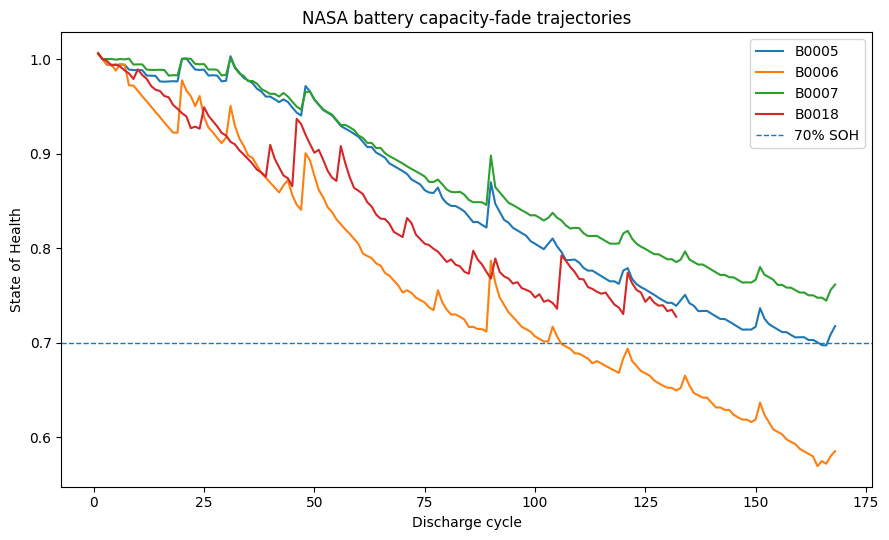

In [6]:
plt.figure(figsize=(9, 5.5))

for battery_id, group in cycle_df.groupby("battery_id"):
    ordered = group.sort_values("cycle_index")

    plt.plot(
        ordered["cycle_index"],
        ordered["soh"],
        label=battery_id,
    )

plt.axhline(EOL_SOH, linestyle="--", linewidth=1, label="70% SOH")
plt.xlabel("Discharge cycle")
plt.ylabel("State of Health")
plt.title("NASA battery capacity-fade trajectories")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIG_DIR / "01_soh_trajectories.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

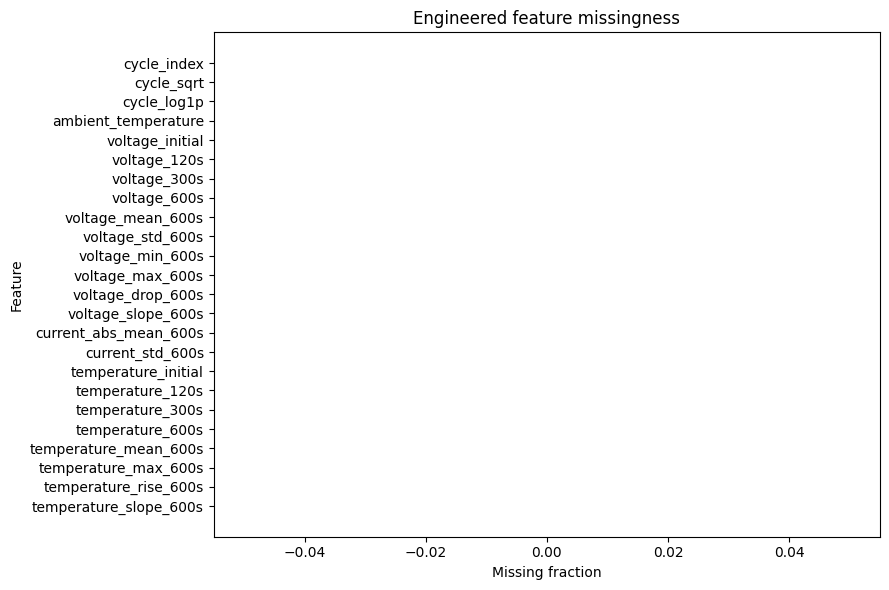

In [7]:
missingness = (
    cycle_df[FEATURE_COLUMNS]
    .isna()
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 6))

plt.barh(
    missingness.index[::-1],
    missingness.values[::-1],
)

plt.xlabel("Missing fraction")
plt.ylabel("Feature")
plt.title("Engineered feature missingness")
plt.tight_layout()

plt.savefig(
    FIG_DIR / "02_feature_missingness.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

### Data-quality and trajectory insights

- All **24 predictive features** are complete for every retained cycle.
- No duplicate `(battery_id, cycle_index)` rows were found.
- The measured trajectories are not perfectly monotonic: the four batteries contain **14–22 short-term SOH increases** above the `0.002` tolerance.
- B0006 falls substantially below the 70% SOH reference, while B0007 remains above approximately 74% throughout the parsed trajectory.
- The zero-height bars in the missingness figure confirm that model comparisons are not being driven by different imputation burdens.

The observed regeneration in the measured data is why the benchmark uses **soft physical penalties** rather than forcing perfectly monotonic predictions.

## 5. Leakage-safe cross-battery protocol

For each held-out battery:

1. all cycles from the held-out battery form the test trajectory;
2. the other three batteries are development batteries;
3. for each development battery, only the earliest requested fraction of cycles is observed;
4. the final 20% of those observed cycles form a temporal validation segment;
5. imputation and scaling are fitted on training data only.

At the 10% setting, the models receive only the earliest 10% of each development battery's life and must predict the complete trajectory of an unseen battery.

In [8]:
@dataclass
class SplitBundle:
    train: pd.DataFrame
    validation: pd.DataFrame
    test: pd.DataFrame
    holdout_battery: str
    data_fraction: float

def make_cross_battery_split(
    frame: pd.DataFrame,
    holdout_battery: str,
    data_fraction: float,
    validation_fraction: float = 0.20,
) -> SplitBundle:
    test = (
        frame[frame["battery_id"] == holdout_battery]
        .sort_values("cycle_index")
        .copy()
    )

    train_parts = []
    validation_parts = []

    for battery_id in BATTERY_IDS:
        if battery_id == holdout_battery:
            continue

        battery = (
            frame[frame["battery_id"] == battery_id]
            .sort_values("cycle_index")
            .copy()
        )

        n_observed = max(
            12,
            int(math.ceil(len(battery) * data_fraction)),
        )

        n_observed = min(n_observed, len(battery))
        observed = battery.iloc[:n_observed].copy()

        n_validation = max(
            2,
            int(math.ceil(len(observed) * validation_fraction)),
        )

        n_validation = min(n_validation, len(observed) - 4)

        train_parts.append(observed.iloc[:-n_validation])
        validation_parts.append(observed.iloc[-n_validation:])

    train = pd.concat(train_parts, ignore_index=True)
    validation = pd.concat(validation_parts, ignore_index=True)

    train_keys = set(zip(train["battery_id"], train["cycle_index"]))
    validation_keys = set(
        zip(validation["battery_id"], validation["cycle_index"])
    )
    test_keys = set(zip(test["battery_id"], test["cycle_index"]))

    if train_keys & validation_keys:
        raise RuntimeError("Train/validation overlap detected")

    if train_keys & test_keys or validation_keys & test_keys:
        raise RuntimeError("Development/test battery overlap detected")

    return SplitBundle(
        train=train,
        validation=validation,
        test=test,
        holdout_battery=holdout_battery,
        data_fraction=data_fraction,
    )

protocol_rows = []

for holdout in BATTERY_IDS:
    for fraction in DATA_FRACTIONS:
        split = make_cross_battery_split(cycle_df, holdout, fraction)

        protocol_rows.append({
            "holdout_battery": holdout,
            "data_fraction": fraction,
            "train_rows": len(split.train),
            "validation_rows": len(split.validation),
            "test_rows": len(split.test),
            "train_batteries": ",".join(
                sorted(split.train["battery_id"].unique())
            ),
        })

protocol_df = pd.DataFrame(protocol_rows)
display(protocol_df)

protocol_df.to_csv(TABLE_DIR / "benchmark_protocol.csv", index=False)

,holdout_battery,data_fraction,train_rows,validation_rows,test_rows,train_batteries
0,B0005,1.00,373,95,168,"B0006,B0007,B0018"
1,B0005,0.50,186,48,168,"B0006,B0007,B0018"
2,B0005,0.25,92,25,168,"B0006,B0007,B0018"
3,B0005,0.10,37,11,168,"B0006,B0007,B0018"
4,B0006,1.00,373,95,168,"B0005,B0007,B0018"
5,B0006,0.50,186,48,168,"B0005,B0007,B0018"
6,B0006,0.25,92,25,168,"B0005,B0007,B0018"
7,B0006,0.10,37,11,168,"B0005,B0007,B0018"
8,B0007,1.00,373,95,168,"B0005,B0006,B0018"
9,B0007,0.50,186,48,168,"B0005,B0006,B0018"


### Split-protocol interpretation

Every test set contains an entirely unseen battery. The remaining batteries contribute only their earliest observed life to development.

- At 100% availability, training contains **373–402 cycles** and validation contains **95–102 cycles**.
- At 10% availability, training falls to only **37–39 cycles**, with **11–12 validation cycles**.
- B0018 has fewer cycles than the other cells, so split sizes vary slightly depending on which battery is held out.

The 10% setting is intentionally severe: the model sees a small early-life sample from three batteries and must predict the full degradation trajectory of a fourth battery.

## 6. Preprocessing and empirical degradation model

The empirical reference is:

\[
\widehat{SOH}(k)=c-a\sqrt{k}-bk
\]

with bounded parameters:

\[
0.90 \le c \le 1.10,\qquad a \ge 0,\qquad b \ge 0
\]

This model encodes a non-increasing degradation prior but cannot use voltage, current, or temperature information.

In [9]:
@dataclass
class PreparedSplit:
    X_train: np.ndarray
    y_train: np.ndarray
    X_validation: np.ndarray
    y_validation: np.ndarray
    X_test: np.ndarray
    y_test: np.ndarray
    train_battery_ids: np.ndarray
    validation_battery_ids: np.ndarray
    test_battery_ids: np.ndarray
    train_cycles: np.ndarray
    validation_cycles: np.ndarray
    test_cycles: np.ndarray
    imputer: SimpleImputer
    scaler: StandardScaler

def prepare_split(split: SplitBundle) -> PreparedSplit:
    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()

    X_train_raw = split.train[FEATURE_COLUMNS]
    X_validation_raw = split.validation[FEATURE_COLUMNS]
    X_test_raw = split.test[FEATURE_COLUMNS]

    X_train_imputed = imputer.fit_transform(X_train_raw)
    X_validation_imputed = imputer.transform(X_validation_raw)
    X_test_imputed = imputer.transform(X_test_raw)

    X_train = scaler.fit_transform(X_train_imputed).astype(np.float32)
    X_validation = scaler.transform(X_validation_imputed).astype(np.float32)
    X_test = scaler.transform(X_test_imputed).astype(np.float32)

    return PreparedSplit(
        X_train=X_train,
        y_train=split.train[TARGET_COLUMN].to_numpy(dtype=np.float32),

        X_validation=X_validation,
        y_validation=split.validation[TARGET_COLUMN].to_numpy(dtype=np.float32),

        X_test=X_test,
        y_test=split.test[TARGET_COLUMN].to_numpy(dtype=np.float32),

        train_battery_ids=split.train["battery_id"].to_numpy(),
        validation_battery_ids=split.validation["battery_id"].to_numpy(),
        test_battery_ids=split.test["battery_id"].to_numpy(),

        train_cycles=split.train["cycle_index"].to_numpy(dtype=np.float32),
        validation_cycles=split.validation["cycle_index"].to_numpy(dtype=np.float32),
        test_cycles=split.test["cycle_index"].to_numpy(dtype=np.float32),

        imputer=imputer,
        scaler=scaler,
    )

def empirical_curve(cycle, parameters):
    c, a, b = parameters
    cycle = np.asarray(cycle, dtype=float)

    return c - a * np.sqrt(np.clip(cycle, 0, None)) - b * cycle

def fit_empirical_curve(cycle, soh):
    cycle = np.asarray(cycle, dtype=float)
    soh = np.asarray(soh, dtype=float)

    result = least_squares(
        lambda parameters: empirical_curve(cycle, parameters) - soh,
        x0=np.array([1.0, 0.004, 0.0002]),
        bounds=(
            np.array([0.90, 0.0, 0.0]),
            np.array([1.10, 0.10, 0.01]),
        ),
        max_nfev=5000,
    )

    return result.x

## 7. Neural architectures and controlled physics penalties

The two direct neural models share the **same bounded architecture**. The two hybrid models also share the **same empirical-residual architecture**. This prevents the benchmark from attributing an architectural difference to physics regularization.

All neural outputs are restricted to a broad physically plausible SOH range:

\[
0.45 \leq \widehat{SOH} \leq 1.08
\]

The optional sequence-physics loss includes:

### Data fit

\[
\mathcal{L}_{data} = \mathrm{MSE}(\widehat{SOH},SOH)
\]

### Soft monotonic degradation

For consecutive cycles from the same training battery:

\[
\mathcal{L}_{mono}
=
\mathrm{mean}
\left[
\max(0,\widehat{SOH}_{k+1}-\widehat{SOH}_k)^2
\right]
\]

### Smoothness

\[
\mathcal{L}_{smooth}
=
\mathrm{mean}
\left[
(\Delta\widehat{SOH}_{k+1}-\Delta\widehat{SOH}_k)^2
\right]
\]

### Initial-SOH anchor and physical range

Predictions near the beginning of life are encouraged toward 1, while range penalties remain as a safeguard.

These are empirical degradation constraints, not a full electrochemical governing-equation PINN. The model is therefore called **physics-regularized**, not strictly monotonic.

In [10]:
class BatteryMLP(nn.Module):
    def __init__(self, n_features: int):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(n_features, 48),
            nn.SiLU(),
            nn.Linear(48, 24),
            nn.SiLU(),
            nn.Linear(24, 1),
        )

        initial_fraction = (
            (1.0 - SOH_MIN)
            / (SOH_MAX - SOH_MIN)
        )
        initial_logit = math.log(
            initial_fraction
            / (1.0 - initial_fraction)
        )

        nn.init.zeros_(
            self.network[-1].weight
        )
        nn.init.constant_(
            self.network[-1].bias,
            initial_logit,
        )

    def forward(self, features, cycle):
        raw = self.network(
            features
        ).squeeze(-1)

        return (
            SOH_MIN
            + (SOH_MAX - SOH_MIN)
            * torch.sigmoid(raw)
        )


class HybridPhysicsResidual(nn.Module):
    def __init__(
        self,
        n_features: int,
        empirical_parameters,
        residual_scale: float = 0.12,
    ):
        super().__init__()

        c, a, b = [
            float(value)
            for value in empirical_parameters
        ]

        self.register_buffer(
            "empirical_parameters",
            torch.tensor(
                [c, a, b],
                dtype=torch.float32,
            ),
        )

        self.residual_scale = residual_scale

        self.residual_network = nn.Sequential(
            nn.Linear(n_features, 32),
            nn.SiLU(),
            nn.Linear(32, 16),
            nn.SiLU(),
            nn.Linear(16, 1),
        )

        nn.init.zeros_(
            self.residual_network[-1].weight
        )
        nn.init.zeros_(
            self.residual_network[-1].bias
        )

    def empirical(self, cycle):
        c, a, b = self.empirical_parameters

        return (
            c
            - a * torch.sqrt(
                torch.clamp(
                    cycle,
                    min=0.0,
                )
            )
            - b * cycle
        )

    def residual(self, features):
        return (
            self.residual_scale
            * torch.tanh(
                self.residual_network(
                    features
                ).squeeze(-1)
            )
        )

    def forward(self, features, cycle):
        raw_prediction = (
            self.empirical(cycle)
            + self.residual(features)
        )

        return torch.clamp(
            raw_prediction,
            min=SOH_MIN,
            max=SOH_MAX,
        )


def tensor_index(indices):
    return torch.as_tensor(
        indices,
        dtype=torch.long,
        device=DEVICE,
    )


def sequence_physics_penalties(
    prediction,
    battery_ids,
    cycles,
):
    monotonic_terms = []
    smoothness_terms = []
    anchor_terms = []

    battery_ids = np.asarray(
        battery_ids
    )
    cycles = np.asarray(
        cycles,
        dtype=float,
    )

    for battery_id in np.unique(
        battery_ids
    ):
        indices = np.where(
            battery_ids == battery_id
        )[0]

        order = indices[
            np.argsort(
                cycles[indices]
            )
        ]

        ordered_prediction = prediction[
            tensor_index(order)
        ]

        if len(order) >= 2:
            first_difference = (
                ordered_prediction[1:]
                - ordered_prediction[:-1]
            )

            monotonic_terms.append(
                torch.relu(
                    first_difference
                )
                .pow(2)
                .mean()
            )

        if len(order) >= 3:
            second_difference = (
                ordered_prediction[2:]
                - 2 * ordered_prediction[1:-1]
                + ordered_prediction[:-2]
            )

            smoothness_terms.append(
                second_difference
                .pow(2)
                .mean()
            )

        first_indices = order[
            : min(
                3,
                len(order),
            )
        ]

        anchor_terms.append(
            (
                prediction[
                    tensor_index(
                        first_indices
                    )
                ]
                - 1.0
            )
            .pow(2)
            .mean()
        )

    zero = prediction.new_tensor(
        0.0
    )

    monotonic = (
        torch.stack(
            monotonic_terms
        ).mean()
        if monotonic_terms
        else zero
    )

    smoothness = (
        torch.stack(
            smoothness_terms
        ).mean()
        if smoothness_terms
        else zero
    )

    anchor = (
        torch.stack(
            anchor_terms
        ).mean()
        if anchor_terms
        else zero
    )

    range_penalty = (
        torch.relu(
            prediction - SOH_MAX
        )
        .pow(2)
        .mean()
        + torch.relu(
            SOH_MIN - prediction
        )
        .pow(2)
        .mean()
    )

    return {
        "monotonic": monotonic,
        "smoothness": smoothness,
        "anchor": anchor,
        "range": range_penalty,
    }


def create_neural_model(
    model_name,
    n_features,
    empirical_parameters,
):
    if model_name in [
        "Data-driven MLP",
        "Physics-regularized MLP",
    ]:
        return BatteryMLP(
            n_features
        )

    if model_name in [
        "Hybrid empirical residual",
        "Hybrid physics residual",
    ]:
        return HybridPhysicsResidual(
            n_features,
            empirical_parameters,
        )

    raise ValueError(
        f"Unknown neural model: {model_name}"
    )

## 8. Neural training with validation-only early stopping

All neural models use the same optimizer and early-stopping protocol. The held-out battery is never used for early stopping.

The controlled losses are:

| Model | Data loss | Residual-size penalty | Sequence-physics penalties |
|---|---:|---:|---:|
| Data-driven MLP | Yes | No | No |
| Physics-regularized MLP | Yes | No | Yes |
| Hybrid empirical residual | Yes | Yes | No |
| Hybrid physics residual | Yes | Yes | Yes |

The small residual-size penalty is shared by both hybrid models so that their difference isolates the sequence-physics terms.

In [11]:
@dataclass
class TrainingResult:
    model: nn.Module
    best_epoch: int
    best_validation_rmse: float
    history: pd.DataFrame


def set_all_seeds(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def predict_torch_model(
    model,
    X,
    cycles,
):
    model.eval()

    with torch.no_grad():
        X_tensor = torch.tensor(
            X,
            dtype=torch.float32,
            device=DEVICE,
        )

        cycle_tensor = torch.tensor(
            cycles,
            dtype=torch.float32,
            device=DEVICE,
        )

        return (
            model(
                X_tensor,
                cycle_tensor,
            )
            .detach()
            .cpu()
            .numpy()
        )


def train_neural_model(
    model_name,
    prepared: PreparedSplit,
    empirical_parameters,
    seed: int,
):
    set_all_seeds(seed)

    model = create_neural_model(
        model_name,
        prepared.X_train.shape[1],
        empirical_parameters,
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    X_train_tensor = torch.tensor(
        prepared.X_train,
        dtype=torch.float32,
        device=DEVICE,
    )

    y_train_tensor = torch.tensor(
        prepared.y_train,
        dtype=torch.float32,
        device=DEVICE,
    )

    cycle_train_tensor = torch.tensor(
        prepared.train_cycles,
        dtype=torch.float32,
        device=DEVICE,
    )

    best_state = None
    best_validation_rmse = np.inf
    best_epoch = -1
    epochs_without_improvement = 0
    history_rows = []

    for epoch in range(
        MAX_EPOCHS
    ):
        model.train()
        optimizer.zero_grad()

        prediction = model(
            X_train_tensor,
            cycle_train_tensor,
        )

        data_loss = (
            prediction
            - y_train_tensor
        ).pow(2).mean()

        total_loss = data_loss

        penalties = {
            "monotonic":
                prediction.new_tensor(0.0),
            "smoothness":
                prediction.new_tensor(0.0),
            "anchor":
                prediction.new_tensor(0.0),
            "range":
                prediction.new_tensor(0.0),
        }

        residual_penalty = (
            prediction.new_tensor(0.0)
        )

        if model_name in [
            "Physics-regularized MLP",
            "Hybrid physics residual",
        ]:
            penalties = (
                sequence_physics_penalties(
                    prediction,
                    prepared.train_battery_ids,
                    prepared.train_cycles,
                )
            )

            total_loss = (
                total_loss
                + PHYSICS_WEIGHTS["monotonic"]
                * penalties["monotonic"]
                + PHYSICS_WEIGHTS["smoothness"]
                * penalties["smoothness"]
                + PHYSICS_WEIGHTS["anchor"]
                * penalties["anchor"]
                + PHYSICS_WEIGHTS["range"]
                * penalties["range"]
            )

        if model_name in [
            "Hybrid empirical residual",
            "Hybrid physics residual",
        ]:
            residual_penalty = (
                model.residual(
                    X_train_tensor
                )
                .pow(2)
                .mean()
            )

            total_loss = (
                total_loss
                + PHYSICS_WEIGHTS["residual"]
                * residual_penalty
            )

        total_loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0,
        )

        optimizer.step()

        validation_prediction = (
            predict_torch_model(
                model,
                prepared.X_validation,
                prepared.validation_cycles,
            )
        )

        validation_rmse = float(
            mean_squared_error(
                prepared.y_validation,
                validation_prediction,
            ) ** 0.5
        )

        history_rows.append({
            "epoch":
                epoch,

            "train_data_mse":
                float(
                    data_loss
                    .detach()
                    .cpu()
                ),

            "train_total_loss":
                float(
                    total_loss
                    .detach()
                    .cpu()
                ),

            "validation_rmse":
                validation_rmse,

            "monotonic_penalty":
                float(
                    penalties["monotonic"]
                    .detach()
                    .cpu()
                ),

            "smoothness_penalty":
                float(
                    penalties["smoothness"]
                    .detach()
                    .cpu()
                ),

            "residual_penalty":
                float(
                    residual_penalty
                    .detach()
                    .cpu()
                ),
        })

        if (
            validation_rmse
            < best_validation_rmse
            - 1e-6
        ):
            best_validation_rmse = (
                validation_rmse
            )

            best_epoch = epoch

            best_state = copy.deepcopy(
                model.state_dict()
            )

            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1

        if (
            epochs_without_improvement
            >= PATIENCE
        ):
            break

    if best_state is None:
        raise RuntimeError(
            f"No valid state was trained for {model_name}"
        )

    model.load_state_dict(
        best_state
    )

    return TrainingResult(
        model=model,
        best_epoch=best_epoch,
        best_validation_rmse=(
            best_validation_rmse
        ),
        history=pd.DataFrame(
            history_rows
        ),
    )

## 9. Metrics for accuracy and physical consistency

Physical diagnostics are computed **within each battery trajectory** before aggregation.

A monotonic violation is counted when predicted SOH increases by more than `0.002` between consecutive cycles of the same battery.

Total regeneration is:

\[
R_{regen}
=
\sum_b
\sum_k
\max(0,\widehat{SOH}_{b,k+1}-\widehat{SOH}_{b,k})
\]

This grouping matters for the final multi-battery validation set, where sorting all batteries together would create artificial jumps between unrelated trajectories.

In [12]:
MONOTONIC_TOLERANCE = 0.002


def regression_metrics(
    y_true,
    prediction,
    cycle,
    battery_ids=None,
    prediction_std=None,
):
    y_true = np.asarray(
        y_true,
        dtype=float,
    )

    prediction = np.asarray(
        prediction,
        dtype=float,
    )

    cycle = np.asarray(
        cycle,
        dtype=float,
    )

    if battery_ids is None:
        battery_ids = np.repeat(
            "single_trajectory",
            len(y_true),
        )
    else:
        battery_ids = np.asarray(
            battery_ids
        )

    monotonic_violation_count = 0
    transition_count = 0
    total_regeneration = 0.0
    late_true_parts = []
    late_prediction_parts = []

    for battery_id in np.unique(
        battery_ids
    ):
        indices = np.where(
            battery_ids == battery_id
        )[0]

        order = indices[
            np.argsort(
                cycle[indices]
            )
        ]

        y_ordered = y_true[
            order
        ]

        prediction_ordered = prediction[
            order
        ]

        difference = np.diff(
            prediction_ordered
        )

        monotonic_violation_count += int(
            (
                difference
                > MONOTONIC_TOLERANCE
            ).sum()
        )

        transition_count += len(
            difference
        )

        total_regeneration += float(
            np.clip(
                difference,
                0,
                None,
            ).sum()
        )

        late_start = max(
            1,
            int(
                math.floor(
                    0.80
                    * len(y_ordered)
                )
            ),
        )

        late_true_parts.append(
            y_ordered[
                late_start:
            ]
        )

        late_prediction_parts.append(
            prediction_ordered[
                late_start:
            ]
        )

    late_true = np.concatenate(
        late_true_parts
    )

    late_prediction = np.concatenate(
        late_prediction_parts
    )

    metrics = {
        "mae":
            float(
                mean_absolute_error(
                    y_true,
                    prediction,
                )
            ),

        "rmse":
            float(
                mean_squared_error(
                    y_true,
                    prediction,
                ) ** 0.5
            ),

        "r2":
            float(
                r2_score(
                    y_true,
                    prediction,
                )
            ),

        "mape_percent":
            float(
                np.mean(
                    np.abs(
                        (
                            y_true
                            - prediction
                        )
                        / np.clip(
                            np.abs(y_true),
                            1e-6,
                            None,
                        )
                    )
                )
                * 100
            ),

        "late_life_rmse":
            float(
                mean_squared_error(
                    late_true,
                    late_prediction,
                ) ** 0.5
            ),

        "monotonic_violation_count":
            monotonic_violation_count,

        "monotonic_violation_rate":
            float(
                monotonic_violation_count
                / transition_count
                if transition_count
                else 0.0
            ),

        "total_regeneration":
            total_regeneration,

        "range_violation_count":
            int(
                (
                    (prediction < SOH_MIN)
                    | (prediction > SOH_MAX)
                ).sum()
            ),
    }

    if prediction_std is not None:
        prediction_std = np.asarray(
            prediction_std,
            dtype=float,
        )

        lower = (
            prediction
            - 1.645
            * prediction_std
        )

        upper = (
            prediction
            + 1.645
            * prediction_std
        )

        metrics[
            "ensemble_90_interval_coverage"
        ] = float(
            (
                (y_true >= lower)
                & (y_true <= upper)
            ).mean()
        )

        metrics[
            "mean_ensemble_std"
        ] = float(
            prediction_std.mean()
        )

    else:
        metrics[
            "ensemble_90_interval_coverage"
        ] = np.nan

        metrics[
            "mean_ensemble_std"
        ] = np.nan

    return metrics

## 10. Complete cross-battery benchmark

The executed benchmark fitted:

```text
4 held-out batteries
× 4 data fractions
× 4 controlled neural variants
× 3 random seeds
= 192 neural fits
```

Sixteen empirical-reference fits were evaluated in parallel. The complete run finished successfully in **5.44 minutes on CUDA**.

The additional hybrid ablation separates the effect of the empirical degradation prior from the additional effect of sequence-physics penalties.

In [13]:
benchmark_metric_rows = []
benchmark_prediction_rows = []
training_log_rows = []

total_neural_fits = (
    len(BATTERY_IDS)
    * len(DATA_FRACTIONS)
    * 4
    * len(BENCHMARK_SEEDS)
)

progress = tqdm(
    total=total_neural_fits,
    desc="Neural benchmark fits",
)

benchmark_start = time.time()

for holdout_battery in BATTERY_IDS:
    for data_fraction in DATA_FRACTIONS:
        split = make_cross_battery_split(
            cycle_df,
            holdout_battery,
            data_fraction,
        )

        prepared = prepare_split(split)

        empirical_parameters = fit_empirical_curve(
            prepared.train_cycles,
            prepared.y_train,
        )

        empirical_prediction = empirical_curve(
            prepared.test_cycles,
            empirical_parameters,
        )

        empirical_metrics = regression_metrics(
            prepared.y_test,
            empirical_prediction,
            prepared.test_cycles,
            prepared.test_battery_ids,
        )

        benchmark_metric_rows.append({
            "holdout_battery": holdout_battery,
            "data_fraction": data_fraction,
            "model": "Empirical degradation",
            "train_rows": len(split.train),
            "validation_rows": len(split.validation),
            "test_rows": len(split.test),
            **empirical_metrics,
        })

        for row_index, row in split.test.reset_index(drop=True).iterrows():
            benchmark_prediction_rows.append({
                "holdout_battery": holdout_battery,
                "data_fraction": data_fraction,
                "model": "Empirical degradation",
                "battery_id": row["battery_id"],
                "cycle_index": int(row["cycle_index"]),
                "true_soh": float(row["soh"]),
                "predicted_soh": float(
                    empirical_prediction[row_index]
                ),
                "prediction_std": 0.0,
            })

        for model_name in [
            "Data-driven MLP",
            "Physics-regularized MLP",
            "Hybrid empirical residual",
            "Hybrid physics residual",
        ]:
            seed_predictions = []

            for seed in BENCHMARK_SEEDS:
                training_result = train_neural_model(
                    model_name,
                    prepared,
                    empirical_parameters,
                    seed,
                )

                test_prediction = predict_torch_model(
                    training_result.model,
                    prepared.X_test,
                    prepared.test_cycles,
                )

                seed_predictions.append(test_prediction)

                training_log_rows.append({
                    "holdout_battery": holdout_battery,
                    "data_fraction": data_fraction,
                    "model": model_name,
                    "seed": seed,
                    "best_epoch": training_result.best_epoch,
                    "best_validation_rmse": (
                        training_result.best_validation_rmse
                    ),
                    "epochs_run": len(training_result.history),
                })

                progress.update(1)

            seed_predictions = np.vstack(seed_predictions)

            ensemble_mean = seed_predictions.mean(axis=0)
            ensemble_std = seed_predictions.std(axis=0)

            metrics = regression_metrics(
                prepared.y_test,
                ensemble_mean,
                prepared.test_cycles,
                prepared.test_battery_ids,
                ensemble_std,
            )

            benchmark_metric_rows.append({
                "holdout_battery": holdout_battery,
                "data_fraction": data_fraction,
                "model": model_name,
                "train_rows": len(split.train),
                "validation_rows": len(split.validation),
                "test_rows": len(split.test),
                **metrics,
            })

            for row_index, row in split.test.reset_index(drop=True).iterrows():
                benchmark_prediction_rows.append({
                    "holdout_battery": holdout_battery,
                    "data_fraction": data_fraction,
                    "model": model_name,
                    "battery_id": row["battery_id"],
                    "cycle_index": int(row["cycle_index"]),
                    "true_soh": float(row["soh"]),
                    "predicted_soh": float(
                        ensemble_mean[row_index]
                    ),
                    "prediction_std": float(
                        ensemble_std[row_index]
                    ),
                })

progress.close()

benchmark_seconds = time.time() - benchmark_start

benchmark_metrics = pd.DataFrame(benchmark_metric_rows)
benchmark_predictions = pd.DataFrame(benchmark_prediction_rows)
training_log = pd.DataFrame(training_log_rows)

benchmark_metrics.to_csv(
    TABLE_DIR / "benchmark_metrics.csv",
    index=False,
)

benchmark_predictions.to_csv(
    TABLE_DIR / "benchmark_predictions.csv",
    index=False,
)

training_log.to_csv(
    TABLE_DIR / "training_log.csv",
    index=False,
)

print(
    "Benchmark completed in",
    round(benchmark_seconds / 60, 2),
    "minutes",
)

display(benchmark_metrics.head())

Neural benchmark fits:   0%|          | 0/192 [00:00<?, ?it/s]

Benchmark completed in 5.44 minutes


,holdout_battery,data_fraction,model,train_rows,validation_rows,test_rows,mae,rmse,r2,mape_percent,late_life_rmse,monotonic_violation_count,monotonic_violation_rate,total_regeneration,range_violation_count,ensemble_90_interval_coverage,mean_ensemble_std
0,B0005,1.0,Empirical degradation,373,95,168,0.041991,0.045516,0.804046,5.058571,0.055557,0,0.000000,0.000000,0,NaN,NaN
1,B0005,1.0,Data-driven MLP,373,95,168,0.029170,0.031906,0.903717,3.526375,0.028225,15,0.089820,0.212094,0,0.089286,0.004041
2,B0005,1.0,Physics-regularized MLP,373,95,168,0.035752,0.040752,0.842923,4.199652,0.019026,13,0.077844,0.090901,0,0.095238,0.005345
3,B0005,1.0,Hybrid empirical residual,373,95,168,0.019113,0.022781,0.950913,2.114412,0.004164,19,0.113772,0.189470,0,0.255952,0.004859
4,B0005,1.0,Hybrid physics residual,373,95,168,0.030408,0.032925,0.897463,3.531338,0.021706,15,0.089820,0.094506,0,0.273810,0.008050


### Benchmark execution status

The complete experiment finished successfully:

```text
192 neural fits
16 empirical-reference fits
3 random seeds per neural candidate
5.44 minutes on CUDA
```

Every reported neural trajectory is the mean of three independently initialized models. The seed standard deviation is retained as a model-spread diagnostic in the exported predictions and metrics.

## 11. Aggregate leaderboard

The leaderboard averages across all four held-out batteries.

No model is declared superior until both prediction error and physical-consistency diagnostics are examined.

In [14]:
leaderboard = (
    benchmark_metrics
    .groupby(
        ["data_fraction", "model"],
        as_index=False,
    )
    .agg(
        mean_mae=("mae", "mean"),
        std_mae=("mae", "std"),
        mean_rmse=("rmse", "mean"),
        std_rmse=("rmse", "std"),
        mean_r2=("r2", "mean"),
        mean_mape_percent=("mape_percent", "mean"),
        mean_late_life_rmse=("late_life_rmse", "mean"),
        mean_monotonic_violation_rate=(
            "monotonic_violation_rate",
            "mean",
        ),
        mean_total_regeneration=(
            "total_regeneration",
            "mean",
        ),
        mean_interval_coverage=(
            "ensemble_90_interval_coverage",
            "mean",
        ),
        mean_ensemble_std=(
            "mean_ensemble_std",
            "mean",
        ),
    )
)

leaderboard = leaderboard.sort_values(
    ["data_fraction", "mean_rmse"],
    ascending=[False, True],
)

leaderboard.to_csv(
    TABLE_DIR / "aggregate_leaderboard.csv",
    index=False,
)

for fraction in DATA_FRACTIONS:
    print("\nDATA FRACTION:", f"{fraction:.0%}")

    display(
        leaderboard[
            leaderboard["data_fraction"] == fraction
        ][
            [
                "model",
                "mean_rmse",
                "std_rmse",
                "mean_mae",
                "mean_r2",
                "mean_late_life_rmse",
                "mean_monotonic_violation_rate",
                "mean_total_regeneration",
            ]
        ]
    )


DATA FRACTION: 100%


,model,mean_rmse,std_rmse,mean_mae,mean_r2,mean_late_life_rmse,mean_monotonic_violation_rate,mean_total_regeneration
19,Physics-regularized MLP,0.027193,0.010606,0.023472,0.917145,0.026985,0.144375,0.199637
15,Data-driven MLP,0.032940,0.012827,0.028420,0.891766,0.036337,0.198976,0.383151
18,Hybrid physics residual,0.040583,0.031839,0.035241,0.817786,0.045088,0.072599,0.099229
17,Hybrid empirical residual,0.041071,0.030298,0.036091,0.812289,0.043719,0.108299,0.188286
16,Empirical degradation,0.061483,0.028513,0.055811,0.556941,0.074299,0.000000,0.000000



DATA FRACTION: 50%


,model,mean_rmse,std_rmse,mean_mae,mean_r2,mean_late_life_rmse,mean_monotonic_violation_rate,mean_total_regeneration
12,Hybrid empirical residual,0.048071,0.001975,0.038723,0.741129,0.084137,0.076530,0.215433
10,Data-driven MLP,0.048501,0.049767,0.040216,0.704336,0.066517,0.146547,0.353852
14,Physics-regularized MLP,0.050364,0.019600,0.039309,0.735589,0.082672,0.121737,0.303904
13,Hybrid physics residual,0.058940,0.016022,0.045700,0.605293,0.102305,0.085924,0.192624
11,Empirical degradation,0.070447,0.043390,0.063129,0.458872,0.090273,0.000000,0.000000



DATA FRACTION: 25%


,model,mean_rmse,std_rmse,mean_mae,mean_r2,mean_late_life_rmse,mean_monotonic_violation_rate,mean_total_regeneration
9,Physics-regularized MLP,0.040449,0.013133,0.031898,0.825857,0.063745,0.151415,0.388756
7,Hybrid empirical residual,0.060300,0.045911,0.051328,0.588464,0.078376,0.102688,0.244730
8,Hybrid physics residual,0.071984,0.041811,0.060859,0.411058,0.102298,0.125554,0.199000
5,Data-driven MLP,0.089984,0.022049,0.071870,0.140905,0.126796,0.157848,0.584350
6,Empirical degradation,0.124236,0.069461,0.105865,-0.655446,0.187489,0.000000,0.000000



DATA FRACTION: 10%


,model,mean_rmse,std_rmse,mean_mae,mean_r2,mean_late_life_rmse,mean_monotonic_violation_rate,mean_total_regeneration
1,Empirical degradation,0.109928,0.080330,0.097037,-0.438949,0.166142,0.000000,0.000000
2,Hybrid empirical residual,0.110459,0.055022,0.091128,-0.231517,0.180736,0.074325,0.136038
4,Physics-regularized MLP,0.112846,0.060502,0.096988,-0.336519,0.143280,0.285688,0.435353
0,Data-driven MLP,0.116248,0.075419,0.095779,-0.436035,0.178107,0.172898,0.312513
3,Hybrid physics residual,0.117303,0.052424,0.098260,-0.401375,0.186532,0.064668,0.146492


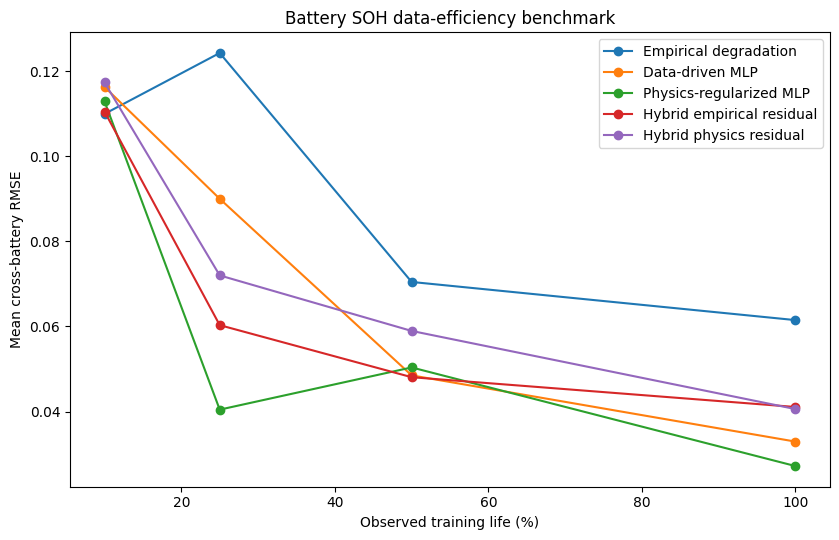

In [15]:
plt.figure(figsize=(8.5, 5.5))

for model_name in MODEL_NAMES:
    subset = (
        leaderboard[
            leaderboard["model"] == model_name
        ]
        .sort_values("data_fraction")
    )

    plt.plot(
        subset["data_fraction"] * 100,
        subset["mean_rmse"],
        marker="o",
        label=model_name,
    )

plt.xlabel("Observed training life (%)")
plt.ylabel("Mean cross-battery RMSE")
plt.title("Battery SOH data-efficiency benchmark")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIG_DIR / "03_data_efficiency_rmse.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

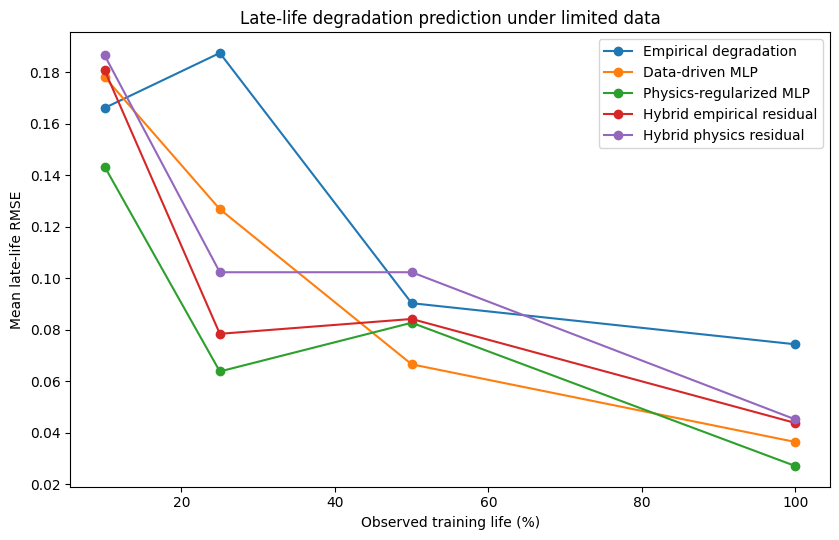

In [16]:
plt.figure(figsize=(8.5, 5.5))

for model_name in MODEL_NAMES:
    subset = (
        leaderboard[
            leaderboard["model"] == model_name
        ]
        .sort_values("data_fraction")
    )

    plt.plot(
        subset["data_fraction"] * 100,
        subset["mean_late_life_rmse"],
        marker="o",
        label=model_name,
    )

plt.xlabel("Observed training life (%)")
plt.ylabel("Mean late-life RMSE")
plt.title("Late-life degradation prediction under limited data")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIG_DIR / "04_data_efficiency_late_life_rmse.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

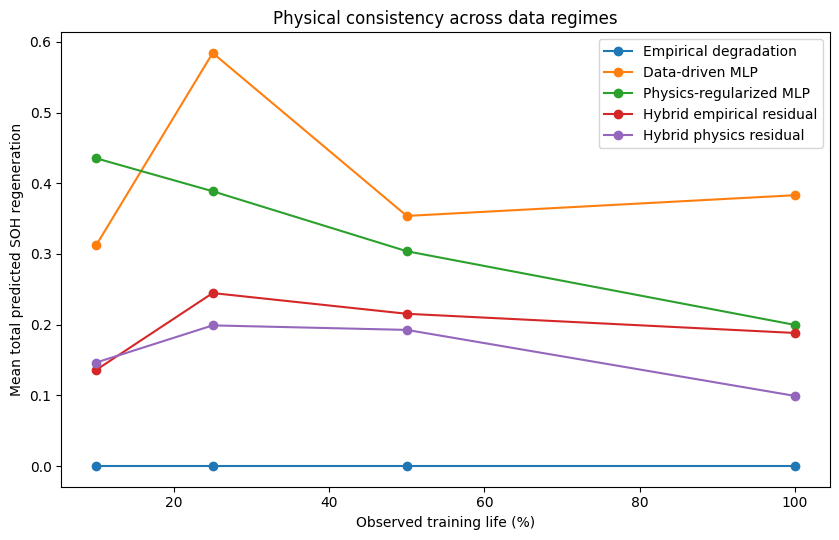

In [17]:
plt.figure(figsize=(8.5, 5.5))

for model_name in MODEL_NAMES:
    subset = (
        leaderboard[
            leaderboard["model"] == model_name
        ]
        .sort_values("data_fraction")
    )

    plt.plot(
        subset["data_fraction"] * 100,
        subset["mean_total_regeneration"],
        marker="o",
        label=model_name,
    )

plt.xlabel("Observed training life (%)")
plt.ylabel("Mean total predicted SOH regeneration")
plt.title("Physical consistency across data regimes")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIG_DIR / "05_physical_regeneration.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

### Data-efficiency and physical-consistency interpretation

Model ranking changes with available development data:

| Observed development life | Lowest mean RMSE | RMSE |
|---:|---|---:|
| 100% | **Physics-regularized MLP** | **0.02719** |
| 50% | **Hybrid empirical residual** | **0.04807** |
| 25% | **Physics-regularized MLP** | **0.04045** |
| 10% | **Empirical degradation** | **0.10993** |

At full data, physics regularization reduces direct-MLP RMSE by about **17.4%**, late-life RMSE by **25.7%**, and total predicted regeneration by **47.9%**.

At 10% data, the empirical curve has the best overall RMSE, although the physics-regularized MLP has the lowest mean late-life RMSE (`0.14328`). This distinction shows that overall trajectory error and terminal-life error can favor different models.

The empirical curve has zero predicted regeneration by construction. Among learned models, lower regeneration does not always correspond to lower RMSE, exposing an accuracy–physical-consistency trade-off.

## 12. Cross-battery results at full development data

This view separates battery-to-battery variation from average performance.

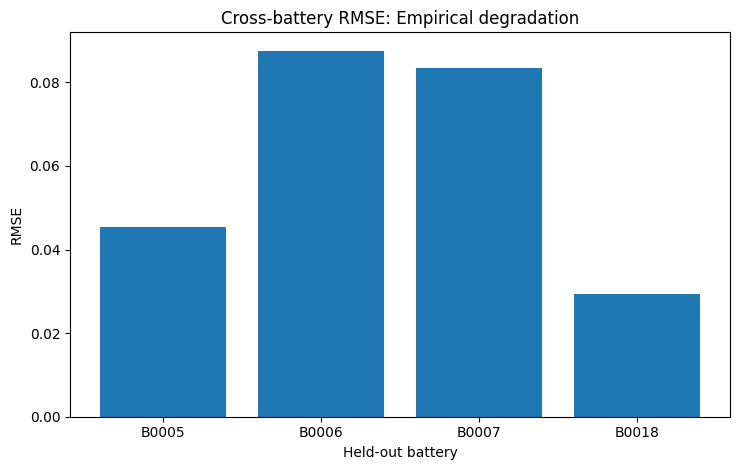

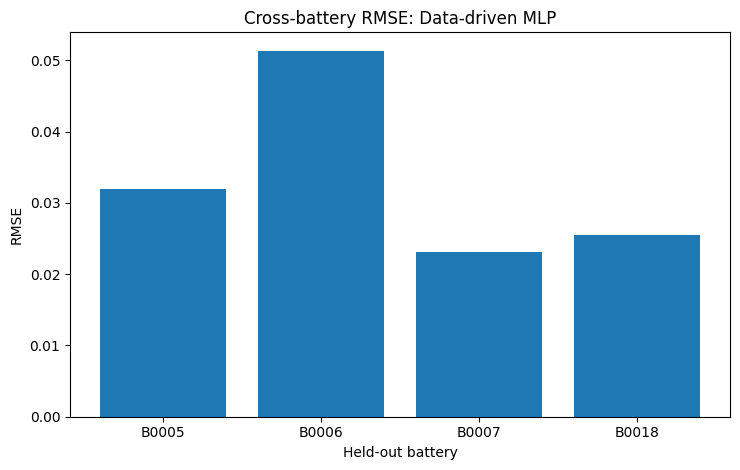

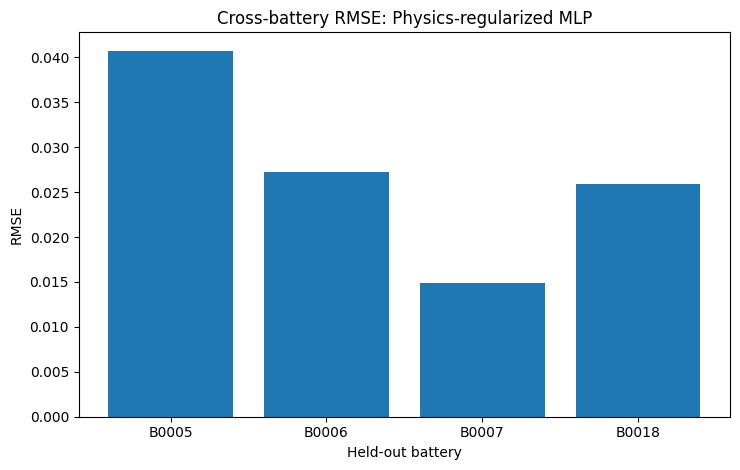

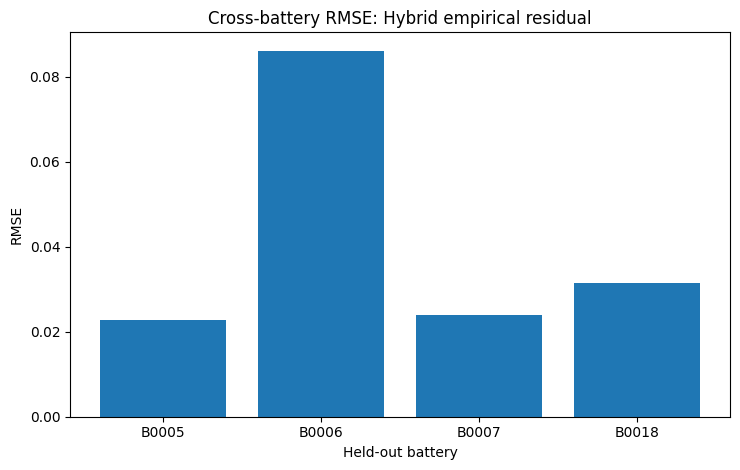

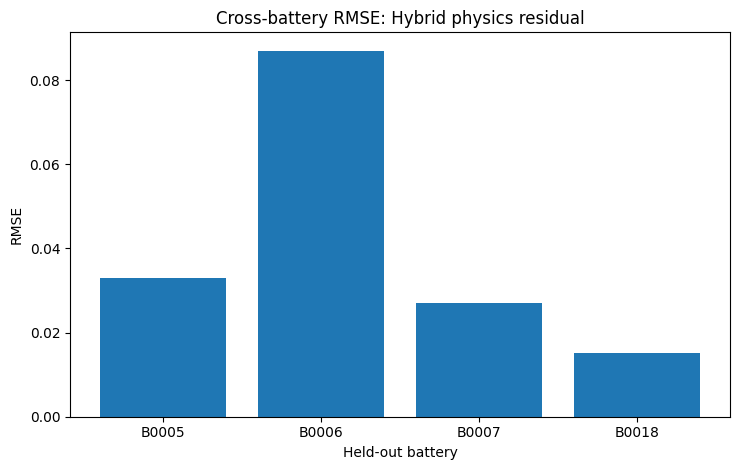

In [18]:
full_data_results = benchmark_metrics[
    benchmark_metrics["data_fraction"] == 1.0
].copy()

for model_name in MODEL_NAMES:
    subset = full_data_results[
        full_data_results["model"] == model_name
    ].sort_values("holdout_battery")

    plt.figure(figsize=(7.5, 4.8))

    plt.bar(
        subset["holdout_battery"],
        subset["rmse"],
    )

    plt.xlabel("Held-out battery")
    plt.ylabel("RMSE")
    plt.title(f"Cross-battery RMSE: {model_name}")
    plt.tight_layout()

    safe_name = (
        model_name.lower()
        .replace(" ", "_")
        .replace("-", "_")
    )

    plt.savefig(
        FIG_DIR / f"06_cross_battery_{safe_name}.png",
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()

### Cross-battery interpretation

The full-data bar charts show that performance varies materially by held-out cell.

- **B0006** is especially difficult for the empirical and hybrid residual models because its late-life decline is steeper than the other trajectories.
- The direct physics penalty improves the data-driven MLP strongly on B0006 and B0007, but slightly worsens it on B0005.
- The hybrid physics residual performs particularly well on B0018, while its performance on B0006 remains comparatively weak.

These differences explain why average performance alone is insufficient. A model can lead the mean leaderboard while still lose on an individual unseen battery.

## 13. Representative held-out trajectories

Each figure shows the complete trajectory of one unseen battery at the **100% development-data** setting.

The plotted neural curves are ensemble means across three seeds. Seed-to-seed standard deviation is exported in the prediction and metric tables, but it is **not shown as a shaded band in these figures**. The ensemble spread is an uncertainty diagnostic rather than a calibrated prediction interval.

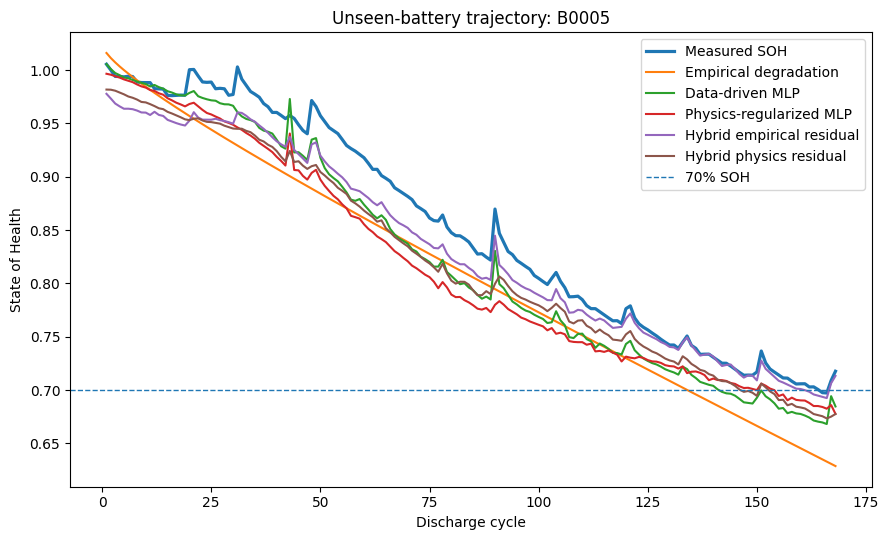

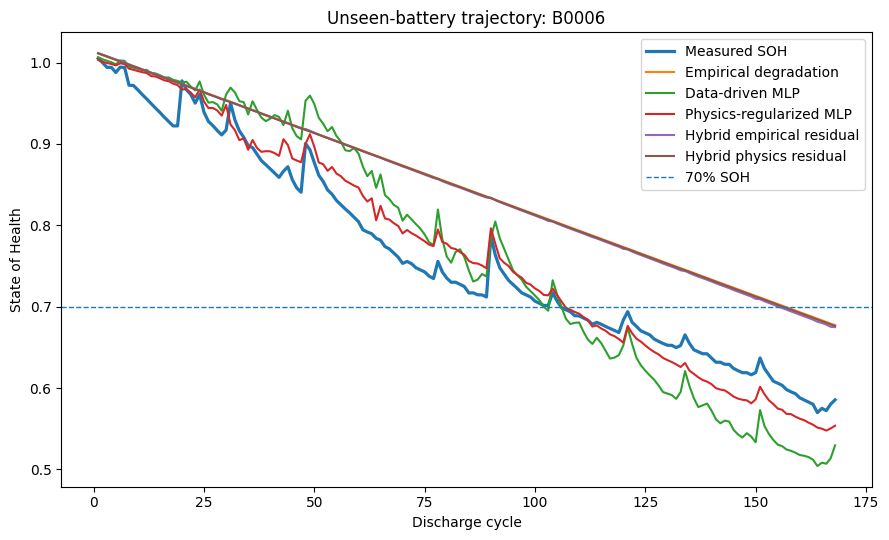

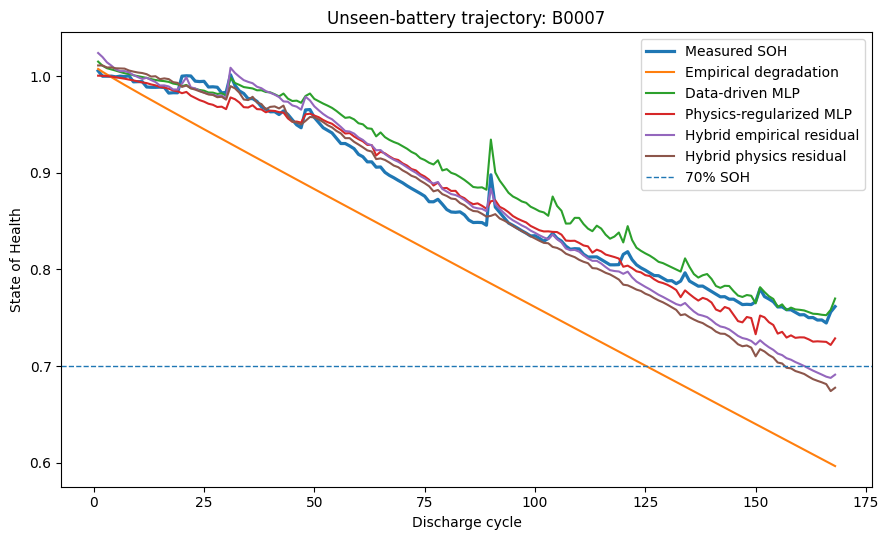

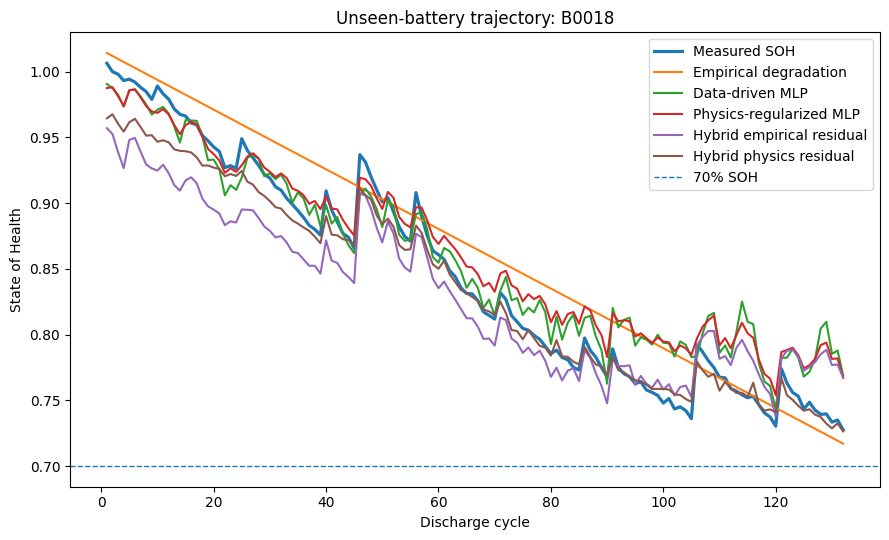

In [19]:
for holdout_battery in BATTERY_IDS:
    subset = benchmark_predictions[
        (
            benchmark_predictions["holdout_battery"]
            == holdout_battery
        )
        & (
            benchmark_predictions["data_fraction"]
            == 1.0
        )
    ].copy()

    truth = (
        subset[
            subset["model"] == "Empirical degradation"
        ][
            ["cycle_index", "true_soh"]
        ]
        .drop_duplicates()
        .sort_values("cycle_index")
    )

    plt.figure(figsize=(9, 5.5))

    plt.plot(
        truth["cycle_index"],
        truth["true_soh"],
        linewidth=2.3,
        label="Measured SOH",
    )

    for model_name in MODEL_NAMES:
        model_data = (
            subset[
                subset["model"] == model_name
            ]
            .sort_values("cycle_index")
        )

        plt.plot(
            model_data["cycle_index"],
            model_data["predicted_soh"],
            label=model_name,
        )

    plt.axhline(
        EOL_SOH,
        linestyle="--",
        linewidth=1,
        label="70% SOH",
    )

    plt.xlabel("Discharge cycle")
    plt.ylabel("State of Health")
    plt.title(f"Unseen-battery trajectory: {holdout_battery}")
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        FIG_DIR / f"07_trajectory_{holdout_battery}.png",
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()

### Held-out trajectory interpretation

The trajectory figures provide context that scalar metrics cannot:

- B0005 contains repeated local capacity recoveries, and several learned models follow the measured decline more closely than the empirical curve.
- B0006 undergoes a pronounced terminal decline; the empirical curve remains too high late in life, while the direct learned models adapt more closely.
- B0007 has a smoother trajectory and is predicted comparatively well by the physics-regularized direct model.
- B0018 is shorter and visibly noisy, with local recovery behavior that challenges strictly monotonic assumptions.

The plotted lines are ensemble means. No shaded uncertainty band is shown; model spread is reported numerically and is not a calibrated confidence interval.

## 14. Controlled ablations: where does the gain come from?

A positive contrast benefit means the candidate has lower RMSE than its matched reference:

\[
\Delta RMSE
=
RMSE_{\mathrm{reference}}
-
RMSE_{\mathrm{candidate}}
\]

The benchmark evaluates four controlled contrasts:

1. **Physics penalty on the direct architecture**  
   Physics-regularized MLP vs data-driven MLP.

2. **Empirical prior / residual architecture**  
   Hybrid empirical residual vs data-driven MLP.

3. **Physics penalty within the hybrid architecture**  
   Hybrid physics residual vs hybrid empirical residual.

4. **Hybrid physics residual vs empirical baseline**  
   The complete hybrid physics model vs the empirical degradation curve.

Because isolated extrapolation failures can dominate an arithmetic mean, the summaries report **median benefit, interquartile range, worst-case benefit, fraction of paired settings improved, and battery-level consistency**.

No formal significance test is claimed: the four data fractions for a battery are dependent, and only four held-out batteries are available.

In [20]:
contrast_specs = [
    {
        "contrast":
            "Physics penalty on direct MLP",
        "reference":
            "Data-driven MLP",
        "candidate":
            "Physics-regularized MLP",
    },
    {
        "contrast":
            "Empirical prior/residual architecture",
        "reference":
            "Data-driven MLP",
        "candidate":
            "Hybrid empirical residual",
    },
    {
        "contrast":
            "Physics penalty within hybrid",
        "reference":
            "Hybrid empirical residual",
        "candidate":
            "Hybrid physics residual",
    },
    {
        "contrast":
            "Hybrid physics residual vs empirical baseline",
        "reference":
            "Empirical degradation",
        "candidate":
            "Hybrid physics residual",
    },
]


rmse_wide = benchmark_metrics.pivot_table(
    index=[
        "holdout_battery",
        "data_fraction",
    ],
    columns="model",
    values="rmse",
)


contrast_rows = []

for spec in contrast_specs:
    for (
        holdout_battery,
        data_fraction,
    ), row in rmse_wide.iterrows():

        reference_rmse = float(
            row[spec["reference"]]
        )

        candidate_rmse = float(
            row[spec["candidate"]]
        )

        benefit = (
            reference_rmse
            - candidate_rmse
        )

        contrast_rows.append({
            "contrast":
                spec["contrast"],
            "reference":
                spec["reference"],
            "candidate":
                spec["candidate"],
            "holdout_battery":
                holdout_battery,
            "data_fraction":
                data_fraction,
            "reference_rmse":
                reference_rmse,
            "candidate_rmse":
                candidate_rmse,
            "rmse_benefit":
                benefit,
            "relative_rmse_benefit":
                benefit
                / max(
                    reference_rmse,
                    1e-12,
                ),
        })


contrast_results = pd.DataFrame(
    contrast_rows
)


contrast_by_fraction = (
    contrast_results
    .groupby(
        [
            "contrast",
            "data_fraction",
        ],
        as_index=False,
    )
    .agg(
        mean_rmse_benefit=(
            "rmse_benefit",
            "mean",
        ),
        median_rmse_benefit=(
            "rmse_benefit",
            "median",
        ),
        mean_relative_benefit=(
            "relative_rmse_benefit",
            "mean",
        ),
        settings_improved=(
            "rmse_benefit",
            lambda values:
                int(
                    (
                        values > 0
                    ).sum()
                ),
        ),
    )
)


battery_level_contrasts = (
    contrast_results
    .groupby(
        [
            "contrast",
            "holdout_battery",
        ],
        as_index=False,
    )
    .agg(
        battery_mean_benefit=(
            "rmse_benefit",
            "mean",
        ),
        battery_median_benefit=(
            "rmse_benefit",
            "median",
        ),
    )
)


overall_rows = []

for spec in contrast_specs:
    subset = contrast_results[
        contrast_results["contrast"]
        == spec["contrast"]
    ]

    battery_subset = battery_level_contrasts[
        battery_level_contrasts[
            "contrast"
        ]
        == spec["contrast"]
    ]

    values = subset[
        "rmse_benefit"
    ].to_numpy()

    q1, q3 = np.quantile(
        values,
        [
            0.25,
            0.75,
        ],
    )

    overall_rows.append({
        "contrast":
            spec["contrast"],
        "reference":
            spec["reference"],
        "candidate":
            spec["candidate"],
        "mean_rmse_benefit":
            float(
                np.mean(
                    values
                )
            ),
        "median_rmse_benefit":
            float(
                np.median(
                    values
                )
            ),
        "iqr_low":
            float(
                q1
            ),
        "iqr_high":
            float(
                q3
            ),
        "worst_case_benefit":
            float(
                np.min(
                    values
                )
            ),
        "best_case_benefit":
            float(
                np.max(
                    values
                )
            ),
        "median_relative_benefit":
            float(
                subset[
                    "relative_rmse_benefit"
                ].median()
            ),
        "fraction_of_settings_improved":
            float(
                (
                    values > 0
                ).mean()
            ),
        "batteries_with_positive_mean_benefit":
            int(
                (
                    battery_subset[
                        "battery_mean_benefit"
                    ]
                    > 0
                ).sum()
            ),
    })


contrast_summary = pd.DataFrame(
    overall_rows
)


contrast_results.to_csv(
    TABLE_DIR
    / "controlled_contrast_results.csv",
    index=False,
)

contrast_by_fraction.to_csv(
    TABLE_DIR
    / "controlled_contrasts_by_fraction.csv",
    index=False,
)

battery_level_contrasts.to_csv(
    TABLE_DIR
    / "controlled_contrasts_by_battery.csv",
    index=False,
)

contrast_summary.to_csv(
    TABLE_DIR
    / "controlled_contrast_summary.csv",
    index=False,
)


print(
    "CONTROLLED CONTRASTS BY DATA FRACTION"
)

display(
    contrast_by_fraction
)


print(
    "\nBATTERY-LEVEL CONTRAST CONSISTENCY"
)

display(
    battery_level_contrasts
)


print(
    "\nOVERALL DESCRIPTIVE CONTRAST SUMMARY"
)

display(
    contrast_summary
)

CONTROLLED CONTRASTS BY DATA FRACTION


,contrast,data_fraction,mean_rmse_benefit,median_rmse_benefit,mean_relative_benefit,settings_improved
0,Empirical prior/residual architecture,0.10,0.005789,0.002217,-0.102083,2
1,Empirical prior/residual architecture,0.25,0.029684,0.032989,0.328542,3
2,Empirical prior/residual architecture,0.50,0.000429,-0.022048,-0.739810,1
3,Empirical prior/residual architecture,1.00,-0.008131,-0.003427,-0.166075,1
4,Hybrid physics residual vs empirical baseline,0.10,-0.007375,-0.008536,-0.447560,2
5,Hybrid physics residual vs empirical baseline,0.25,0.052252,0.058702,0.383272,3
6,Hybrid physics residual vs empirical baseline,0.50,0.011506,-0.000364,-0.053825,2
7,Hybrid physics residual vs empirical baseline,1.00,0.020900,0.013423,0.360234,4
8,Physics penalty on direct MLP,0.10,0.003402,0.018734,-0.188058,3
9,Physics penalty on direct MLP,0.25,0.049534,0.056188,0.529405,4



BATTERY-LEVEL CONTRAST CONSISTENCY


,contrast,holdout_battery,battery_mean_benefit,battery_median_benefit
0,Empirical prior/residual architecture,B0005,0.029393,0.025565
1,Empirical prior/residual architecture,B0006,0.007823,-0.005638
2,Empirical prior/residual architecture,B0007,-0.003817,-0.007561
3,Empirical prior/residual architecture,B0018,-0.005627,-0.014687
4,Hybrid physics residual vs empirical baseline,B0005,0.000880,-0.010510
5,Hybrid physics residual vs empirical baseline,B0006,0.050120,0.053410
6,Hybrid physics residual vs empirical baseline,B0007,0.018845,0.010340
7,Hybrid physics residual vs empirical baseline,B0018,0.007438,0.006100
8,Physics penalty on direct MLP,B0005,0.011428,0.002774
9,Physics penalty on direct MLP,B0006,0.037091,0.035679



OVERALL DESCRIPTIVE CONTRAST SUMMARY


,contrast,reference,candidate,mean_rmse_benefit,median_rmse_benefit,iqr_low,iqr_high,worst_case_benefit,best_case_benefit,median_relative_benefit,fraction_of_settings_improved,batteries_with_positive_mean_benefit
0,Physics penalty on direct MLP,Data-driven MLP,Physics-regularized MLP,0.014205,0.015834,-0.006942,0.035189,-0.055024,0.068486,0.195835,0.6250,4
1,Empirical prior/residual architecture,Data-driven MLP,Hybrid empirical residual,0.006943,-0.003427,-0.024392,0.030277,-0.034794,0.082823,-0.115827,0.4375,2
2,Physics penalty within hybrid,Hybrid empirical residual,Hybrid physics residual,-0.007227,-0.005016,-0.017984,0.002739,-0.029675,0.016288,-0.137423,0.3125,1
3,Hybrid physics residual vs empirical baseline,Empirical degradation,Hybrid physics residual,0.019321,0.013423,-0.001636,0.054533,-0.038883,0.093101,0.139415,0.6875,4


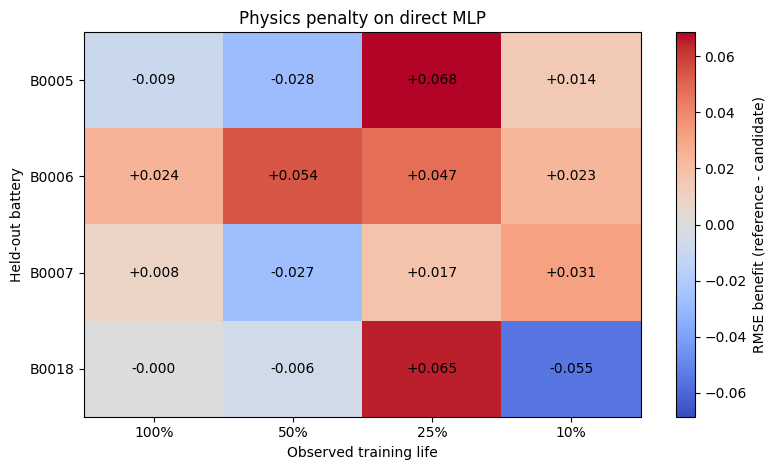

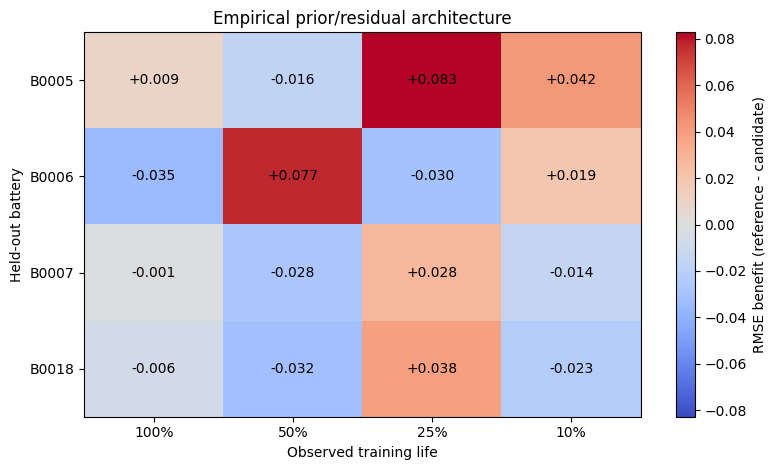

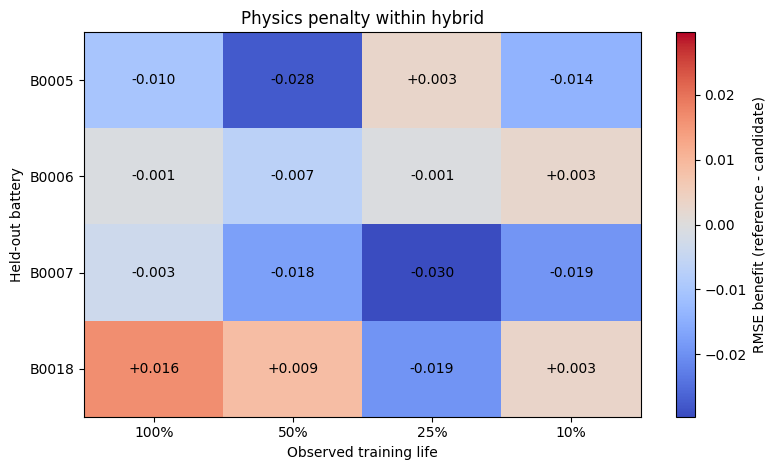

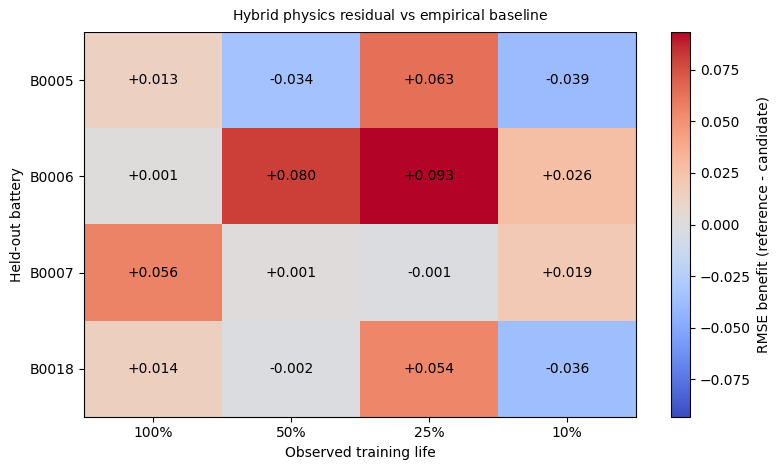

In [21]:
for spec in contrast_specs:
    contrast_name = spec[
        "contrast"
    ]

    matrix = (
        contrast_results[
            contrast_results[
                "contrast"
            ]
            == contrast_name
        ]
        .pivot(
            index="holdout_battery",
            columns="data_fraction",
            values="rmse_benefit",
        )
        .reindex(
            index=BATTERY_IDS,
            columns=DATA_FRACTIONS,
        )
    )

    plt.figure(
        figsize=(8.0, 4.8)
    )

    max_abs = float(
        np.nanmax(
            np.abs(
                matrix.to_numpy()
            )
        )
    )

    if max_abs == 0:
        max_abs = 1.0

    image = plt.imshow(
        matrix.to_numpy(),
        aspect="auto",
        cmap="coolwarm",
        vmin=-max_abs,
        vmax=max_abs,
    )

    plt.colorbar(
        image,
        label=(
            "RMSE benefit "
            "(reference - candidate)"
        ),
    )

    plt.xticks(
        range(
            len(
                DATA_FRACTIONS
            )
        ),
        [
            f"{fraction:.0%}"
            for fraction
            in DATA_FRACTIONS
        ],
    )

    plt.yticks(
        range(
            len(
                BATTERY_IDS
            )
        ),
        BATTERY_IDS,
    )

    plt.xlabel(
        "Observed training life"
    )

    plt.ylabel(
        "Held-out battery"
    )

    plt.title(
        contrast_name
    )

    for row_index in range(
        len(
            BATTERY_IDS
        )
    ):
        for column_index in range(
            len(
                DATA_FRACTIONS
            )
        ):
            value = matrix.iloc[
                row_index,
                column_index,
            ]

            plt.text(
                column_index,
                row_index,
                f"{value:+.3f}",
                ha="center",
                va="center",
            )

    plt.tight_layout()

    safe_name = (
        contrast_name
        .lower()
        .replace(
            " ",
            "_",
        )
        .replace(
            "/",
            "_",
        )
    )

    plt.savefig(
        FIG_DIR
        / f"08_contrast_{safe_name}.png",
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()

### Controlled-ablation interpretation

The paired ablations separate architecture from regularization:

| Controlled contrast | Median RMSE benefit | Settings improved | Positive mean benefit by battery |
|---|---:|---:|---:|
| Physics penalty on direct MLP | **+0.01583** | **62.5%** | **4/4** |
| Empirical prior / residual architecture | −0.00343 | 43.8% | 2/4 |
| Physics penalty within hybrid | −0.00502 | 31.2% | 1/4 |
| Hybrid physics residual vs empirical baseline | **+0.01342** | **68.8%** | **4/4** |

The direct physics penalty is beneficial overall, but the heatmap shows important exceptions, including a substantial loss for B0018 at 10% data.

The empirical hybrid architecture is inconsistent by itself, and adding sequence-physics penalties inside that matched hybrid generally makes predictive RMSE worse. Therefore, the strongest conclusion is **architecture-specific**: physics regularization helps the matched direct MLP, but it is not a universal improvement mechanism.

## 15. Evidence-based benchmark summary

The final interpretation is based on matched architecture comparisons, battery-disjoint error, low-data behavior, late-life error, and physical consistency.

The evidence supports a conditional conclusion:

- physics regularization improved the matched direct MLP overall;
- that benefit was not universal across every battery and data fraction;
- an empirical hybrid architecture alone was inconsistent;
- adding sequence-physics penalties inside the hybrid generally reduced predictive accuracy;
- the simple empirical curve remained the strongest overall model at the extreme 10% data setting.

In [22]:
full_leaderboard = (
    leaderboard[
        leaderboard[
            "data_fraction"
        ]
        == 1.0
    ]
    .sort_values(
        [
            "mean_rmse",
            "mean_total_regeneration",
        ]
    )
    .reset_index(
        drop=True
    )
)


low_data_leaderboard = (
    leaderboard[
        leaderboard[
            "data_fraction"
        ]
        == 0.10
    ]
    .sort_values(
        [
            "mean_rmse",
            "mean_total_regeneration",
        ]
    )
    .reset_index(
        drop=True
    )
)


best_full_model = str(
    full_leaderboard
    .iloc[0][
        "model"
    ]
)


best_low_data_model = str(
    low_data_leaderboard
    .iloc[0][
        "model"
    ]
)


print(
    "BENCHMARK SUMMARY"
)

print(
    "=" * 72
)

print(
    "Best model at 100% development data:",
    best_full_model,
)

print(
    "Best model at 10% development data:",
    best_low_data_model,
)

print()


display(
    full_leaderboard[
        [
            "model",
            "mean_rmse",
            "std_rmse",
            "mean_mae",
            "mean_r2",
            "mean_late_life_rmse",
            "mean_monotonic_violation_rate",
            "mean_total_regeneration",
            "mean_interval_coverage",
        ]
    ]
)


print(
    "\nCONTROLLED ABLATION SUMMARY"
)


display(
    contrast_summary[
        [
            "contrast",
            "mean_rmse_benefit",
            "median_rmse_benefit",
            "median_relative_benefit",
            "iqr_low",
            "iqr_high",
            "worst_case_benefit",
            "fraction_of_settings_improved",
            "batteries_with_positive_mean_benefit",
        ]
    ]
)


print(
    "\nEVIDENCE-BASED INTERPRETATION"
)


for _, row in contrast_summary.iterrows():
    direction = (
        "improved"
        if row[
            "median_rmse_benefit"
        ]
        > 0
        else "did not improve"
    )

    print(
        f"- {row['contrast']}: "
        f"{direction} median RMSE by "
        f"{abs(row['median_rmse_benefit']):.5f}; "
        f"candidate won "
        f"{row['fraction_of_settings_improved']:.1%} "
        f"of paired settings; "
        f"worst-case benefit="
        f"{row['worst_case_benefit']:+.5f}; "
        f"positive mean benefit on "
        f"{int(row['batteries_with_positive_mean_benefit'])}/4 batteries."
    )


print(
    "- Physics regularization improved the matched direct MLP "
    "overall, but the worst-case paired result remained negative; "
    "the benefit is conditional rather than universal."
)

print(
    "- The empirical-prior hybrid architecture was inconsistent, "
    "and adding sequence-physics penalties inside that matched "
    "hybrid generally reduced predictive accuracy."
)

print(
    "- The empirical degradation curve was the strongest overall "
    "model when only 10% of development life was observed."
)

print(
    "- The Physics-regularized MLP is the primary learned candidate "
    "because it achieved the best full-data battery-disjoint RMSE."
)

print(
    "- Ensemble spread is an uncertainty diagnostic, "
    "not a calibrated predictive interval."
)

BENCHMARK SUMMARY
Best model at 100% development data: Physics-regularized MLP
Best model at 10% development data: Empirical degradation



,model,mean_rmse,std_rmse,mean_mae,mean_r2,mean_late_life_rmse,mean_monotonic_violation_rate,mean_total_regeneration,mean_interval_coverage
0,Physics-regularized MLP,0.027193,0.010606,0.023472,0.917145,0.026985,0.144375,0.199637,0.391504
1,Data-driven MLP,0.032940,0.012827,0.028420,0.891766,0.036337,0.198976,0.383151,0.317776
2,Hybrid physics residual,0.040583,0.031839,0.035241,0.817786,0.045088,0.072599,0.099229,0.261634
3,Hybrid empirical residual,0.041071,0.030298,0.036091,0.812289,0.043719,0.108299,0.188286,0.182224
4,Empirical degradation,0.061483,0.028513,0.055811,0.556941,0.074299,0.000000,0.000000,NaN



CONTROLLED ABLATION SUMMARY


,contrast,mean_rmse_benefit,median_rmse_benefit,median_relative_benefit,iqr_low,iqr_high,worst_case_benefit,fraction_of_settings_improved,batteries_with_positive_mean_benefit
0,Physics penalty on direct MLP,0.014205,0.015834,0.195835,-0.006942,0.035189,-0.055024,0.6250,4
1,Empirical prior/residual architecture,0.006943,-0.003427,-0.115827,-0.024392,0.030277,-0.034794,0.4375,2
2,Physics penalty within hybrid,-0.007227,-0.005016,-0.137423,-0.017984,0.002739,-0.029675,0.3125,1
3,Hybrid physics residual vs empirical baseline,0.019321,0.013423,0.139415,-0.001636,0.054533,-0.038883,0.6875,4


EVIDENCE-BASED INTERPRETATION
- Physics penalty on direct MLP: improved median RMSE by 0.01583; candidate won 62.5% of paired settings; worst-case benefit=-0.05502; positive mean benefit on 4/4 batteries.
- Empirical prior/residual architecture: did not improve median RMSE; median benefit=-0.00343; candidate won 43.8% of paired settings; positive mean benefit on 2/4 batteries.
- Physics penalty within hybrid: did not improve median RMSE; median benefit=-0.00502; candidate won 31.2% of paired settings; positive mean benefit on 1/4 batteries.
- Hybrid physics residual vs empirical baseline: improved median RMSE by 0.01342; candidate won 68.8% of paired settings; worst-case benefit=-0.03888; positive mean benefit on 4/4 batteries.
- Physics regularization improved the matched direct MLP overall, but the worst-case paired result remained negative; the benefit is conditional rather than universal.
- The empirical-prior hybrid architecture was inconsistent, and adding sequence-physics penalt

### Main scientific interpretation

At full development data, the **Physics-regularized MLP** is the strongest battery-disjoint model:

- mean RMSE: **0.02719**
- mean MAE: **0.02347**
- mean \(R^2\): **0.9171**
- late-life RMSE: **0.02698**

Relative to the matched data-driven MLP, it reduces mean RMSE by approximately **17.4%**, late-life RMSE by **25.7%**, and predicted regeneration by **47.9%**.

However, physics is not uniformly beneficial:

- the direct physics penalty loses in 37.5% of paired battery/data settings;
- sequence-physics penalties generally reduce accuracy inside the matched hybrid;
- at 10% observed life, the empirical curve is the best overall model.

The nominal 90% ensemble coverage for the selected full-data model is only **39.2%**. Seed-to-seed spread must therefore be described as **ensemble dispersion**, not as a calibrated 90% predictive interval.

## 16. Final candidate ensembles

The final artifact-training stage fits all four neural candidates using all available batteries, with the earliest 85% of each battery used for training and the latest 15% used for temporal validation.

This stage creates deployable preprocessing and model artifacts. It is **not additional held-out evidence** and does not replace the leave-one-battery-out benchmark used for model selection.

Saved assets include:

- feature imputer and scaler;
- empirical degradation parameters;
- data-driven and physics-regularized direct MLP ensembles;
- empirical and physics-regularized hybrid residual ensembles;
- CPU-portable state dictionaries and TorchScript models;
- feature schema, metadata, and deployment recommendation.

In [23]:
def make_final_development_split(
    frame,
    validation_fraction=0.15,
):
    train_parts = []
    validation_parts = []

    for battery_id in BATTERY_IDS:
        battery = (
            frame[
                frame["battery_id"] == battery_id
            ]
            .sort_values("cycle_index")
            .copy()
        )

        n_validation = max(
            4,
            int(
                math.ceil(
                    len(battery) * validation_fraction
                )
            ),
        )

        train_parts.append(
            battery.iloc[:-n_validation]
        )

        validation_parts.append(
            battery.iloc[-n_validation:]
        )

    return (
        pd.concat(train_parts, ignore_index=True),
        pd.concat(validation_parts, ignore_index=True),
    )

final_train, final_validation = make_final_development_split(
    cycle_df
)

final_split = SplitBundle(
    train=final_train,
    validation=final_validation,
    test=final_validation.copy(),
    holdout_battery="none_final_training",
    data_fraction=1.0,
)

final_prepared = prepare_split(final_split)

final_empirical_parameters = fit_empirical_curve(
    final_prepared.train_cycles,
    final_prepared.y_train,
)

joblib.dump(
    final_prepared.imputer,
    ARTIFACT_DIR / "feature_imputer.joblib",
)

joblib.dump(
    final_prepared.scaler,
    ARTIFACT_DIR / "feature_scaler.joblib",
)

with (ARTIFACT_DIR / "empirical_parameters.json").open("w") as f:
    json.dump(
        {
            "c": float(final_empirical_parameters[0]),
            "a_sqrt_cycle": float(final_empirical_parameters[1]),
            "b_cycle": float(final_empirical_parameters[2]),
            "formula": "SOH = c - a*sqrt(cycle) - b*cycle",
        },
        f,
        indent=2,
    )

final_validation_rows = []

for model_name in [
    "Data-driven MLP",
    "Physics-regularized MLP",
    "Hybrid empirical residual",
    "Hybrid physics residual",
]:
    model_directory = (
        ARTIFACT_DIR
        / model_name.lower()
        .replace(" ", "_")
        .replace("-", "_")
    )

    model_directory.mkdir(
        parents=True,
        exist_ok=True,
    )

    seed_predictions = []

    for seed in BENCHMARK_SEEDS:
        result = train_neural_model(
            model_name,
            final_prepared,
            final_empirical_parameters,
            seed,
        )

        validation_prediction = predict_torch_model(
            result.model,
            final_prepared.X_validation,
            final_prepared.validation_cycles,
        )

        seed_predictions.append(validation_prediction)

        state_path = (
            model_directory
            / f"model_seed_{seed}.pth"
        )

        cpu_model = copy.deepcopy(
            result.model
        ).to("cpu").eval()

        cpu_state = {
            key: value.detach().cpu()
            for key, value
            in cpu_model.state_dict().items()
        }

        torch.save(
            cpu_state,
            state_path,
        )

        example_features = torch.tensor(
            final_prepared.X_validation[:2],
            dtype=torch.float32,
        )

        example_cycles = torch.tensor(
            final_prepared.validation_cycles[:2],
            dtype=torch.float32,
        )

        traced = torch.jit.trace(
            cpu_model,
            (
                example_features,
                example_cycles,
            ),
        )

        traced.save(
            str(
                model_directory
                / (
                    f"model_seed_{seed}"
                    "_torchscript.pt"
                )
            )
        )

        history_name = (
            model_name.lower()
            .replace(" ", "_")
            .replace("-", "_")
        )

        result.history.assign(
            model=model_name,
            seed=seed,
        ).to_csv(
            TABLE_DIR
            / f"final_training_history_{history_name}_seed_{seed}.csv",
            index=False,
        )

    seed_predictions = np.vstack(seed_predictions)

    mean_prediction = seed_predictions.mean(axis=0)
    std_prediction = seed_predictions.std(axis=0)

    metrics = regression_metrics(
        final_prepared.y_validation,
        mean_prediction,
        final_prepared.validation_cycles,
        final_prepared.validation_battery_ids,
        std_prediction,
    )

    final_validation_rows.append({
        "model": model_name,
        **metrics,
    })

empirical_validation_prediction = empirical_curve(
    final_prepared.validation_cycles,
    final_empirical_parameters,
)

final_validation_rows.append({
    "model": "Empirical degradation",
    **regression_metrics(
        final_prepared.y_validation,
        empirical_validation_prediction,
        final_prepared.validation_cycles,
        final_prepared.validation_battery_ids,
    ),
})

final_candidate_validation = (
    pd.DataFrame(final_validation_rows)
    .sort_values(
        ["rmse", "total_regeneration"]
    )
)

final_candidate_validation.to_csv(
    TABLE_DIR / "final_candidate_validation.csv",
    index=False,
)

display(final_candidate_validation)

,model,mae,rmse,r2,mape_percent,late_life_rmse,monotonic_violation_count,monotonic_violation_rate,total_regeneration,range_violation_count,ensemble_90_interval_coverage,mean_ensemble_std
0,Data-driven MLP,0.004945,0.006943,0.988321,0.715166,0.010070,15,0.159574,0.216639,0,0.530612,0.002624
1,Physics-regularized MLP,0.005936,0.007888,0.984927,0.868133,0.010720,18,0.191489,0.134528,0,0.357143,0.001905
2,Hybrid empirical residual,0.006887,0.008306,0.983286,0.998164,0.012329,10,0.106383,0.129134,0,0.326531,0.002680
3,Hybrid physics residual,0.011148,0.014186,0.951250,1.629302,0.021664,10,0.106383,0.097846,0,0.183673,0.002300
4,Empirical degradation,0.056170,0.063707,0.016765,8.102376,0.072716,0,0.000000,0.000000,0,NaN,NaN


### Final artifact-training interpretation

The all-battery temporal validation stage gives the lowest RMSE to the data-driven MLP (`0.00694`), followed by the Physics-regularized MLP (`0.00789`). This does **not** overturn the benchmark selection:

- this final stage trains on all known batteries and evaluates later cycles from those same batteries;
- the leave-one-battery-out benchmark tests transfer to a completely unseen cell;
- the Physics-regularized MLP remains the recommended learned model because it achieved the best average full-data cross-battery RMSE.

All four neural candidates are retained as artifacts so downstream engineering can preserve the benchmark evidence rather than hiding alternative models.

## 17. Save schemas, metadata, and recommendation

The deployment recommendation is derived from the **cross-battery full-data leaderboard**, not from the final all-battery validation split alone.

In [24]:
feature_schema = {
    "target": {
        "name": "soh",
        "definition": (
            "measured discharge capacity divided by the "
            "median of the first three valid discharge capacities"
        ),
    },
    "input_window_seconds": EARLY_WINDOW_SECONDS,
    "feature_count": len(FEATURE_COLUMNS),
    "feature_names": FEATURE_COLUMNS,
    "excluded_from_inputs": [
        "capacity_ah",
        "reference_capacity_ah",
        "soh",
        "total discharge duration",
        "battery_id",
    ],
    "expected_raw_signals": [
        "Voltage_measured",
        "Current_measured",
        "Temperature_measured",
        "Time",
        "ambient_temperature",
    ],
}

with (ARTIFACT_DIR / "feature_schema.json").open("w") as f:
    json.dump(feature_schema, f, indent=2)

benchmark_selected_model = str(
    full_leaderboard.iloc[0]["model"]
)

recommendation = {
    "benchmark_selected_model": benchmark_selected_model,
    "selection_basis": (
        "lowest mean leave-one-battery-out RMSE at "
        "100% development data; physical consistency "
        "used as a secondary criterion"
    ),
    "best_low_data_model_10_percent": str(
        low_data_leaderboard.iloc[0]["model"]
    ),
    "available_artifacts": [
        "Empirical degradation",
        "Data-driven MLP ensemble",
        "Physics-regularized MLP ensemble",
        "Hybrid empirical residual ensemble",
        "Hybrid physics residual ensemble",
    ],
    "research_use_only": True,
}

with (
    ARTIFACT_DIR
    / "deployment_recommendation.json"
).open("w") as f:
    json.dump(recommendation, f, indent=2)

clean_manifest = manifest_df.copy()
clean_manifest["size_mb"] = clean_manifest["size_mb"].astype(float)

full_data_records = json.loads(
    full_leaderboard.to_json(
        orient="records"
    )
)

contrast_records = json.loads(
    contrast_summary.to_json(
        orient="records"
    )
)

manifest_records = json.loads(
    clean_manifest.to_json(
        orient="records"
    )
)

metadata = {
    "study": "Physics-aware battery SOH benchmark",
    "dataset": "NASA Ames PCoE Li-ion Battery Aging Dataset",
    "download_mirror": selected_dataset_handle,
    "batteries": BATTERY_IDS,
    "data_fractions": DATA_FRACTIONS,
    "seeds": BENCHMARK_SEEDS,
    "early_window_seconds": EARLY_WINDOW_SECONDS,
    "feature_count": len(FEATURE_COLUMNS),
    "benchmark_runtime_seconds": benchmark_seconds,
    "physics_weights": PHYSICS_WEIGHTS,
    "controlled_contrasts": contrast_records,
    "benchmark_selected_model": benchmark_selected_model,
    "best_low_data_model": str(
        low_data_leaderboard.iloc[0]["model"]
    ),
    "full_data_leaderboard": full_data_records,
    "file_manifest": manifest_records,
}

with (
    RESULTS_DIR
    / "benchmark_summary.json"
).open("w") as f:
    json.dump(
        metadata,
        f,
        indent=2,
        allow_nan=False,
    )

print("Benchmark-selected model:", benchmark_selected_model)
print(
    "Best 10% data model:",
    recommendation["best_low_data_model_10_percent"],
)
print("Artifacts saved to:", ARTIFACT_DIR)

Benchmark-selected model: Physics-regularized MLP
Best 10% data model: Empirical degradation
Artifacts saved to: /content/physics_aware_battery_soh/artifacts


## 18. Exported benchmark summary

The following cell writes `BENCHMARK_SUMMARY.md` using the measured winners and controlled-ablation values.

The exported conclusion states the actual result: **physics regularization improved the matched direct MLP overall, but not universally; sequence-physics penalties did not improve the matched hybrid architecture; and the empirical degradation curve was strongest when only 10% of development life was observed.**

In [25]:
best_full_row = (
    full_leaderboard.iloc[0]
)

best_low_row = (
    low_data_leaderboard.iloc[0]
)


summary_lines = [
    (
        "# Physics-Aware Battery SOH "
        "Benchmark — Result Summary"
    ),
    "",
    "## Study",
    "",
    (
        "- Dataset: NASA Ames PCoE "
        "Li-ion Battery Aging Dataset"
    ),
    (
        "- Batteries: "
        + ", ".join(
            BATTERY_IDS
        )
    ),
    (
        "- Early-discharge feature window: "
        f"{EARLY_WINDOW_SECONDS:.0f} seconds"
    ),
    (
        f"- Features: "
        f"{len(FEATURE_COLUMNS)}"
    ),
    (
        "- Cross-battery protocol: "
        "leave one battery out"
    ),
    (
        "- Data regimes: "
        "100%, 50%, 25%, 10%"
    ),
    (
        "- Neural ensemble seeds: "
        f"{BENCHMARK_SEEDS}"
    ),
    "",
    "## Best average model",
    "",
    "### Full development data",
    "",
    (
        "- Model: "
        f"**{best_full_row['model']}**"
    ),
    (
        "- Mean RMSE: "
        f"**{best_full_row['mean_rmse']:.5f}**"
    ),
    (
        "- Mean MAE: "
        f"**{best_full_row['mean_mae']:.5f}**"
    ),
    (
        "- Mean late-life RMSE: "
        f"**{best_full_row['mean_late_life_rmse']:.5f}**"
    ),
    (
        "- Mean total regeneration: "
        f"**{best_full_row['mean_total_regeneration']:.5f}**"
    ),
    "",
    "### 10% observed development life",
    "",
    (
        "- Model: "
        f"**{best_low_row['model']}**"
    ),
    (
        "- Mean RMSE: "
        f"**{best_low_row['mean_rmse']:.5f}**"
    ),
    (
        "- Mean MAE: "
        f"**{best_low_row['mean_mae']:.5f}**"
    ),
    (
        "- Mean late-life RMSE: "
        f"**{best_low_row['mean_late_life_rmse']:.5f}**"
    ),
    "",
    "## Controlled ablations",
    "",
]


for _, row in contrast_summary.iterrows():
    summary_lines.extend([
        (
            "### "
            + str(
                row[
                    "contrast"
                ]
            )
        ),
        "",
        (
            "- Mean RMSE benefit: "
            f"**{row['mean_rmse_benefit']:+.5f}**"
        ),
        (
            "- Median RMSE benefit: "
            f"**{row['median_rmse_benefit']:+.5f}**"
        ),
        (
            "- Median relative benefit: "
            f"**{row['median_relative_benefit']:+.1%}**"
        ),
        (
            "- Fraction of paired settings improved: "
            f"**{row['fraction_of_settings_improved']:.1%}**"
        ),
        (
            "- Worst-case RMSE benefit: "
            f"**{row['worst_case_benefit']:+.5f}**"
        ),
        (
            "- Batteries with positive mean benefit: "
            f"**{int(row['batteries_with_positive_mean_benefit'])}/4**"
        ),
        "",
    ])


summary_lines.extend([
    (
        "A positive RMSE benefit means the "
        "candidate reduced RMSE relative to "
        "its matched reference."
    ),
    "",
    "## Final interpretation",
    "",
    (
        "Physics regularization improved the matched direct MLP "
        "overall and produced the strongest full-data cross-battery "
        "result, but the gain was not universal across every battery "
        "and data fraction."
    ),
    "",
    (
        "The empirical-prior hybrid architecture alone was "
        "inconsistent. Adding sequence-physics penalties inside "
        "the matched hybrid generally reduced predictive accuracy."
    ),
    "",
    (
        "At the extreme 10% data setting, the empirical degradation "
        "curve achieved the lowest overall RMSE, supporting a "
        "data-regime-aware model strategy."
    ),
    "",
    (
        "The three-seed ensemble spread is an uncertainty diagnostic "
        "only and is not a calibrated prediction interval."
    ),
    "",
    "## Downstream model recommendation",
    "",
    (
        "- Primary learned SOH model: "
        "**Physics-regularized MLP ensemble**"
    ),
    (
        "- Transparent low-data reference: "
        "**Empirical degradation curve**"
    ),
    (
        "- Research comparison artifacts: data-driven MLP and "
        "both hybrid residual variants"
    ),
    "",
    "## Research scope",
    "",
    (
        "These results support an independent physics-aware "
        "benchmarking study. They are not certified battery-"
        "management, control, remaining-life, or safety claims."
    ),
])


summary_markdown = "\n".join(
    summary_lines
)


(
    RESULTS_DIR
    / "BENCHMARK_SUMMARY.md"
).write_text(
    summary_markdown
)


print(
    summary_markdown
)

# Physics-Aware Battery SOH Benchmark — Result Summary

## Study

- Dataset: NASA Ames PCoE Li-ion Battery Aging Dataset
- Batteries: B0005, B0006, B0007, B0018
- Parsed discharge cycles: 636
- Early-discharge feature window: 600 seconds
- Predictive features: 24
- Evaluation: battery-disjoint leave-one-cell-out
- Data regimes: 100%, 50%, 25%, 10%
- Neural ensemble seeds: [13, 42, 77]
- Benchmark runtime: 5.44 minutes

## Main benchmark outcome

- Best full-data model: **Physics-regularized MLP**
- Full-data mean RMSE: **0.02719**
- Full-data mean MAE: **0.02347**
- Full-data mean R²: **0.9171**
- Full-data late-life RMSE: **0.02698**
- RMSE reduction vs matched data-driven MLP: **17.4%**
- Late-life RMSE reduction vs matched data-driven MLP: **25.7%**
- Predicted regeneration reduction vs matched data-driven MLP: **47.9%**

## Extreme low-data outcome

- Best model with 10% observed development life: **Empirical degradation**
- Mean RMSE: **0.10993**
- Mean MAE: **0.09704**
- Mean lat

## 19. Reproducibility package

The executed notebook created `physics_aware_battery_soh_outputs.zip` with a final size of **3.02 MB**.

It contains:

- benchmark metrics and predictions;
- aggregate leaderboards and controlled-ablation tables;
- all generated figures;
- preprocessing objects;
- empirical parameters;
- final candidate ensembles and TorchScript models;
- feature schema, dataset hashes, metadata, and the exported result summary.

It intentionally excludes the raw NASA `.mat` files, the private derived cycle table, and Kaggle cache content, avoiding redistribution of the source dataset.

In [26]:
OUTPUT_ZIP = Path(
    "/content/physics_aware_battery_soh_outputs.zip"
)

if OUTPUT_ZIP.exists():
    OUTPUT_ZIP.unlink()

with zipfile.ZipFile(
    OUTPUT_ZIP,
    "w",
    zipfile.ZIP_DEFLATED,
) as archive:
    for source_root in [
        RESULTS_DIR,
        ARTIFACT_DIR,
    ]:
        for path in source_root.rglob("*"):
            if path.is_file():
                archive.write(
                    path,
                    path.relative_to(ROOT),
                )

print("Created:", OUTPUT_ZIP)

print(
    "Archive size:",
    round(
        OUTPUT_ZIP.stat().st_size
        / 1024**2,
        2,
    ),
    "MB",
)

DOWNLOAD_OUTPUTS = True

if DOWNLOAD_OUTPUTS:
    from google.colab import files
    files.download(str(OUTPUT_ZIP))

Created: /content/physics_aware_battery_soh_outputs.zip
Archive size: 3.02 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Reproducibility output

The final **3.02 MB** ZIP was created successfully. It contains the measured evidence and deployable artifacts needed for the integrated energy-intelligence project, while excluding raw source data.

The package is suitable for model inspection, result verification, documentation, and downstream software development. Scientific attribution and dataset-access instructions remain necessary because the raw NASA files are not redistributed.

## 20. Conclusions

This benchmark supports five evidence-based conclusions:

1. **Physics regularization helps the matched direct MLP overall.**  
   It improves median paired RMSE by `0.01583` (`19.6%` relative), wins `62.5%` of battery/data settings, and has positive mean benefit on all four held-out batteries.

2. **The benefit is conditional rather than universal.**  
   The worst paired direct-MLP result is negative (`−0.05502`), and the winning model changes with data availability.

3. **Sequence-physics penalties are architecture-dependent.**  
   They improve the direct MLP overall but generally reduce predictive accuracy inside the matched hybrid residual architecture.

4. **Simple empirical modeling remains valuable in extreme low-data regimes.**  
   With only 10% of development life observed, the empirical degradation curve has the lowest overall mean RMSE (`0.10993`).

5. **Accuracy, physical consistency, and uncertainty must be reported separately.**  
   The selected Physics-regularized MLP improves both error and regeneration relative to the direct MLP, but its three-seed spread is not a calibrated interval.

### Recommended downstream use

```text
Primary learned SOH model
└── Physics-regularized MLP ensemble

Transparent low-data reference
└── Empirical degradation curve

Research comparison artifacts
├── Data-driven MLP
├── Hybrid empirical residual
└── Hybrid physics residual
```

### GitHub publication status

The notebook is suitable for publication as an **independent physics-aware battery SOH benchmark**. It should not be described as an exact reproduction of the cited paper or as a certified battery-management, control, remaining-life, or safety system.

## References

1. Wang, F., Zhai, Z., Zhao, Z., Di, Y., Chen, X. et al. *Physics-informed neural network for lithium-ion battery degradation stable modeling and prognosis.* Nature Communications 15, 4332 (2024). https://doi.org/10.1038/s41467-024-48779-z  
2. NASA Ames Prognostics Center of Excellence. *Li-ion Battery Aging Datasets.* NASA Open Data Portal / PCoE Data Repository.  
3. Saha, B. & Goebel, K. *Battery Data Set.* NASA Ames Prognostics Data Repository.  
4. Public Kaggle download mirrors are used only to automate retrieval of the original NASA MATLAB files.